# Can LLMs Reason Causally? Probing Causal Inference Across Pearl's Hierarchy

**A systematic evaluation of causal reasoning capabilities in Large Language Models.**

Can Large Language Models perform genuine causal reasoning, or do they merely exploit
statistical shortcuts? This notebook investigates how LLM causal reasoning ability varies
across Pearl's Causal Hierarchy, model scale, and prompting strategies.

| Model | Parameters | Type | Quantization |
|-------|-----------|------|-------------|
| GPT-2 Small | 124M | Base (autoregressive) | FP32 |
| GPT-2 Large | 774M | Base (autoregressive) | FP32 |
| Phi-2 | 2.7B | Instruction-tuned | 4-bit (NF4) |

**Key contributions:**
1. **Structured causal reasoning benchmark** spanning 5 canonical causal graphs and all 3 levels of Pearl's Ladder of Causation (association, intervention, counterfactual)
2. **Systematic evaluation** of 3 models x 3 reasoning levels x 4 prompting strategies
3. **Internal representation analysis** via linear probing and attention pattern visualization -- going beyond behavioral testing to understand *how* models process causal information
4. **Scaling analysis** showing how causal reasoning (dis)improves with model size

This notebook complements our CausalVAE study (causal structure *learning* in vision models)
by examining causal *reasoning* in language models -- together they demonstrate breadth
across the causal inference landscape.

## 1. Motivation

### Why Causal Reasoning Matters for LLMs

LLMs trained on internet-scale text learn rich statistical patterns, but **correlation
is not causation**. When an LLM says "smoking causes cancer," does it truly understand
the causal mechanism, or has it merely memorized the co-occurrence of these concepts?

This distinction has critical implications:
- **AI Safety**: A model that confuses correlation with causation may give dangerous
  medical or policy advice
- **Robustness**: Causal understanding is invariant to distribution shift; statistical
  shortcuts are not
- **Trustworthiness**: Users need to know whether an LLM's causal claims reflect genuine
  reasoning or pattern matching

### Pearl's Ladder of Causation

Judea Pearl's Causal Hierarchy defines three levels of causal reasoning, each strictly
more powerful than the last:

| Level | Name | Question | Typical Query | Requires |
|-------|------|----------|--------------|----------|
| L1 | **Association** | "What if I observe...?" | P(Y \| X) | Passive observation |
| L2 | **Intervention** | "What if I do...?" | P(Y \| do(X)) | Manipulating variables |
| L3 | **Counterfactual** | "What if I had done...?" | P(Y_x \| X', Y') | Imagining alternatives |

**Key insight**: An agent that masters L1 can compute any conditional probability but
cannot distinguish confounding from causation. L2 requires understanding that *intervening*
on X (do-calculus) differs from *observing* X when confounders exist. L3 requires reasoning
about what *would have happened* in an alternative world.

### This Study

We construct a benchmark of causal reasoning problems across all three levels and five
canonical causal graph structures, then evaluate whether LLMs of different scales can
solve them. We go beyond accuracy scores to probe the models' internal representations,
asking: **do LLMs encode causal structure, or do they succeed (when they do) via
surface-level heuristics?**

In [1]:
# ============================================================================
# 1. Setup & Installation
# ============================================================================
!pip install -q transformers accelerate bitsandbytes torch numpy scipy \
    scikit-learn matplotlib seaborn networkx tqdm pandas

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import json, math, random, copy, warnings, gc, os
from collections import defaultdict
from pathlib import Path
from tqdm.auto import tqdm
from itertools import product

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig, logging as hf_logging
)

hf_logging.set_verbosity_error()
warnings.filterwarnings('ignore')
# C5: filter the two mistune / nbconvert SyntaxWarnings about invalid
# escape sequences in regex literals. They originate in dependencies and
# are benign, but they clutter Kaggle logs.
warnings.filterwarnings('ignore', category=SyntaxWarning, module='mistune.*')
warnings.filterwarnings('ignore', category=SyntaxWarning, module='nbconvert.*')
# C5: silence the pydevd 'frozen modules' debugger warning on Kaggle.
os.environ.setdefault('PYDEVD_DISABLE_FILE_VALIDATION', '1')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# C2: Also seed the transformers RNG so HF utilities (sampling, dropout fallbacks,
# data-collator shuffles) are reproducible across runs.
try:
    from transformers import set_seed as _hf_set_seed
    _hf_set_seed(SEED)
except Exception:
    pass

# C5: small helper used in the evaluation cells. Calling torch.cuda.empty_cache()
# between model passes keeps Kaggle T4 from fragmenting memory on long runs.
def _maybe_empty_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")

# --- HuggingFace authentication sanity check (runtime-aware) ---
# Llama and Gemma require accepting a license on huggingface.co and an HF token.
# GPT-2 and Qwen are ungated and work without a token.
# This block tries, in order:
#   1) Kaggle Secrets (add secret named "HF_TOKEN" in the Kaggle notebook sidebar)
#   2) Colab userdata (if a secret named "HF_TOKEN" is set)
#   3) an existing env variable HF_TOKEN / HUGGING_FACE_HUB_TOKEN
#   4) the token cached by `huggingface-cli login`
# Never hardcode tokens in the notebook.

# 1) Kaggle
try:
    from kaggle_secrets import UserSecretsClient  # available inside Kaggle notebooks
    try:
        _kaggle_tok = UserSecretsClient().get_secret("HF_TOKEN")
        if _kaggle_tok:
            os.environ["HF_TOKEN"] = _kaggle_tok
            print("HF_TOKEN loaded from Kaggle Secrets.")
    except Exception as _ke:
        print(f"[INFO] Running on Kaggle but HF_TOKEN secret not configured ({_ke}).")
except ImportError:
    pass

# 2) Colab
if not os.environ.get("HF_TOKEN"):
    try:
        from google.colab import userdata  # available inside Colab notebooks
        try:
            _colab_tok = userdata.get("HF_TOKEN")
            if _colab_tok:
                os.environ["HF_TOKEN"] = _colab_tok
                print("HF_TOKEN loaded from Colab userdata.")
        except Exception:
            pass
    except ImportError:
        pass

# 3) + 4) env var / cached CLI login
_HF_TOKEN_PRESENT = bool(os.environ.get('HF_TOKEN') or os.environ.get('HUGGING_FACE_HUB_TOKEN'))
try:
    from huggingface_hub import HfFolder
    _HF_TOKEN_PRESENT = _HF_TOKEN_PRESENT or bool(HfFolder.get_token())
except Exception:
    pass

if not _HF_TOKEN_PRESENT:
    print("\n[INFO] No HuggingFace token detected.")
    print("       GPT-2 (all sizes) and Qwen2.5 will still load fine.")
    print("       Llama-3.2 and Gemma-2 are license-gated and will be SKIPPED unless you:")
    print("         1) accept the license on https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct")
    print("            and https://huggingface.co/google/gemma-2-2b-it")
    print("         2) set up HF_TOKEN via one of:")
    print("             - Kaggle:  Sidebar → Add-ons → Secrets → add 'HF_TOKEN'")
    print("             - Colab:   Left sidebar → Secrets (key icon) → add 'HF_TOKEN'")
    print("             - Local:   run `huggingface-cli login` or `export HF_TOKEN=...`")
else:
    print("HuggingFace token is available -- license-gated models (Llama, Gemma) will download.")

print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.7 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4 (15.6 GB)
Setup complete.


## 2. Background: Causal Graphs and Reasoning Levels

### 2.1 Structural Causal Models (SCMs)

A Structural Causal Model $\mathcal{M} = (U, V, F, P(U))$ consists of:
- **Exogenous variables** $U$ (unobserved noise)
- **Endogenous variables** $V$ (observed)
- **Structural equations** $F$: each $V_i = f_i(\text{Pa}(V_i), U_i)$
- **Distribution** $P(U)$ over noise terms

The causal graph $\mathcal{G}$ is the DAG induced by the structural equations.

### 2.2 Four Canonical Causal Structures

We test LLMs on four fundamental graph topologies:

1. **Chain** ($X \to Y \to Z$): Mediation. $X$ causes $Z$ only through $Y$.
2. **Fork** ($X \leftarrow C \to Z$): Common cause / confounder. $X$ and $Z$ are
   correlated but neither causes the other.
3. **Collider** ($X \to M \leftarrow Z$): Explaining away. $X$ and $Z$ are
   marginally independent but become dependent when conditioning on $M$.
4. **Diamond** ($X \to \{Y, Z\} \to W$): Multiple pathways from $X$ to $W$.

### 2.3 Three Levels of Causal Reasoning

**Level 1 -- Association** $P(Y | X = x)$:
> "Given that we *see* $X = x$, what do we expect for $Y$?"

Standard conditional probability. Confounders bias the answer.

**Level 2 -- Intervention** $P(Y | \text{do}(X = x))$:
> "If we *force* $X = x$ (removing all incoming edges to $X$), what happens to $Y$?"

Requires the truncated factorization formula:
$$P(Y | \text{do}(X = x)) = \sum_z P(Y | X = x, Z = z) P(Z = z)$$
(back-door adjustment when $Z$ is a valid adjustment set)

**Level 3 -- Counterfactual** $P(Y_{x} | X = x', Y = y')$:
> "We *observed* $X = x'$ and $Y = y'$. What *would* $Y$ have been if $X$ had been $x$?"

Requires three steps: (1) Abduction -- infer $U$ from evidence, (2) Action -- intervene,
(3) Prediction -- compute the outcome in the modified model.

### 2.4 Key Distinction: Where Association ≠ Intervention

The **collider** and **fork** structures are critical tests:

- **Fork** ($X \leftarrow C \to Y$): Observing $X$ is informative about $Y$
  (through the confounder $C$), but intervening $\text{do}(X)$ severs the $C \to X$
  link, so $Y$ is unaffected. *Association overestimates the causal effect.*

- **Collider** ($X \to M \leftarrow Y$): $X$ and $Y$ are marginally independent,
  but conditioning on $M$ creates a spurious association (Berkson's paradox).
  *Conditioning creates a false "causal" signal.*


In [2]:
# ============================================================================
# 2. Configuration
# ============================================================================

# Models to evaluate
MODEL_CONFIGS = {
    # --- Pretrained LM scaling curve (GPT-2 family, MIT license) ---
    'gpt2_small': {
        'name': 'gpt2',
        'display_name': 'GPT-2 Small',
        'params': '124M',
        'quantize': False,
    },
    'gpt2_large': {
        'name': 'gpt2-large',
        'display_name': 'GPT-2 Large',
        'params': '774M',
        'quantize': False,
    },
    # --- Modern instruction-tuned models (4-bit NF4 for memory) ---
    'qwen_1_5b': {
        'name': 'Qwen/Qwen2.5-1.5B-Instruct',
        'display_name': 'Qwen2.5-1.5B-Instruct',
        'params': '1.5B',
        'quantize': True,    # Apache 2.0, no license acceptance needed
    },
    'llama_3_3b': {
        'name': 'meta-llama/Llama-3.2-3B-Instruct',
        'display_name': 'Llama-3.2-3B-Instruct',
        'params': '3.2B',
        'quantize': True,    # Needs Meta license acceptance + HF_TOKEN
    },
    'gemma_2_2b': {
        'name': 'google/gemma-2-2b-it',
        'display_name': 'Gemma-2-2B-it',
        'params': '2.6B',
        'quantize': True,    # Needs Google Gemma license acceptance + HF_TOKEN
    },
}

# Benchmark settings
NUM_QUESTIONS_PER_CELL = 20  # Per graph type per reasoning level
MAX_SEQ_LEN = 512  # default for GPT-2 models
MODEL_MAX_SEQ_LEN = {
    'gpt2_small': 512,
    'gpt2_large': 512,
    'qwen_1_5b':  2048,   # Qwen2.5 supports 32k; 2048 is plenty
    'llama_3_3b': 2048,   # Llama-3.2 supports 128k; 2048 is plenty
    'gemma_2_2b': 2048,   # Gemma-2 supports 8k; 2048 is plenty
}

# Prompting strategies
PROMPTING_STRATEGIES = ['zero_shot', 'few_shot', 'chain_of_thought', 'causal_chain']

# Probing settings
PROBE_NUM_SAMPLES = 200  # Number of samples for probing analysis
PROBE_CV_FOLDS = 5

# Output
OUTPUT_DIR = Path('./output_llm')
OUTPUT_DIR.mkdir(exist_ok=True)

# Colors for plots
MODEL_COLORS = {
    'gpt2_small':  '#4C72B0',  # blue
    'gpt2_large':  '#DD8452',  # orange
    'qwen_1_5b':   '#8172B3',  # purple
    'llama_3_3b':  '#C44E52',  # red
    'gemma_2_2b':  '#937860',  # brown
}
MODEL_LABELS = {
    'gpt2_small':  'GPT-2 Small (124M)',
    'gpt2_large':  'GPT-2 Large (774M)',
    'qwen_1_5b':   'Qwen2.5-1.5B-Inst',
    'llama_3_3b':  'Llama-3.2-3B-Inst',
    'gemma_2_2b':  'Gemma-2-2B-it',
}
LEVEL_COLORS = {'L1': '#4C72B0', 'L2': '#DD8452', 'L3': '#C44E52'}

print("Configuration set.")
print(f"  Models: {', '.join(MODEL_LABELS.values())}")
print(f"  Questions: {NUM_QUESTIONS_PER_CELL} per graph type per level")
print(f"  Prompting strategies: {PROMPTING_STRATEGIES}")
print(f"  Output directory: {OUTPUT_DIR}")

Configuration set.
  Models: GPT-2 Small (124M), GPT-2 Large (774M), Qwen2.5-1.5B-Inst, Llama-3.2-3B-Inst, Gemma-2-2B-it
  Questions: 20 per graph type per level
  Prompting strategies: ['zero_shot', 'few_shot', 'chain_of_thought', 'causal_chain']
  Output directory: output_llm


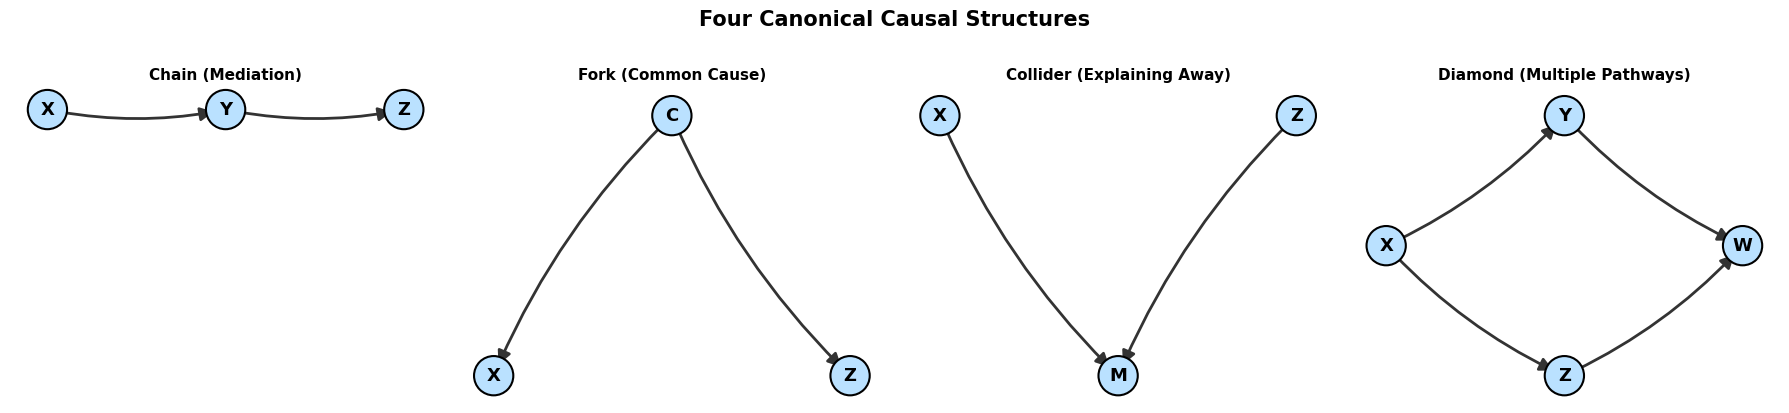

  Chain (Mediation)              | Edges: [('X', 'Y'), ('Y', 'Z')]
                                 | X causes Z only through mediator Y.

  Fork (Common Cause)            | Edges: [('C', 'X'), ('C', 'Z')]
                                 | C is a common cause (confounder) of X and Z. X and Z are correlated but neither causes the other.

  Collider (Explaining Away)     | Edges: [('X', 'M'), ('Z', 'M')]
                                 | X and Z are independent causes of M. Conditioning on M induces spurious dependence between X and Z.

  Diamond (Multiple Pathways)    | Edges: [('X', 'Y'), ('X', 'Z'), ('Y', 'W'), ('Z', 'W')]
                                 | X influences W through two parallel mediators Y and Z.



In [3]:
# ============================================================================
# 3. Causal Graph Definitions
# ============================================================================

# Define the 4 canonical causal structures
CAUSAL_GRAPHS = {
    'chain': {
        'edges': [('X', 'Y'), ('Y', 'Z')],
        'description': 'Chain (Mediation)',
        'variables': ['X', 'Y', 'Z'],
        'mechanism': 'X causes Z only through mediator Y.',
    },
    'fork': {
        'edges': [('C', 'X'), ('C', 'Z')],
        'description': 'Fork (Common Cause)',
        'variables': ['C', 'X', 'Z'],
        'mechanism': 'C is a common cause (confounder) of X and Z. X and Z are correlated but neither causes the other.',
    },
    'collider': {
        'edges': [('X', 'M'), ('Z', 'M')],
        'description': 'Collider (Explaining Away)',
        'variables': ['X', 'Z', 'M'],
        'mechanism': 'X and Z are independent causes of M. Conditioning on M induces spurious dependence between X and Z.',
    },
    'diamond': {
        'edges': [('X', 'Y'), ('X', 'Z'), ('Y', 'W'), ('Z', 'W')],
        'description': 'Diamond (Multiple Pathways)',
        'variables': ['X', 'Y', 'Z', 'W'],
        'mechanism': 'X influences W through two parallel mediators Y and Z.',
    },
}

# Visualize all causal graphs
n_graphs = len(CAUSAL_GRAPHS)
fig, axes = plt.subplots(1, n_graphs, figsize=(4.5 * n_graphs, 4))
if n_graphs == 1:
    axes = [axes]

layout_overrides = {
    'chain':      {'X': (0, 0), 'Y': (1, 0), 'Z': (2, 0)},
    'fork':       {'C': (1, 1), 'X': (0, 0), 'Z': (2, 0)},
    'collider':   {'X': (0, 1), 'Z': (2, 1), 'M': (1, 0)},
    'diamond':    {'X': (0, 1), 'Y': (1, 2), 'Z': (1, 0), 'W': (2, 1)},
}

for idx, (gname, ginfo) in enumerate(CAUSAL_GRAPHS.items()):
    ax = axes[idx]
    G = nx.DiGraph()
    G.add_edges_from(ginfo['edges'])

    pos = layout_overrides[gname]

    node_colors = ['#BAE1FF' for _ in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=800, edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=13, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#333333',
                           arrows=True, arrowsize=20, width=2,
                           connectionstyle='arc3,rad=0.1')
    ax.set_title(f'{ginfo["description"]}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Four Canonical Causal Structures', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'causal_graphs.png', dpi=150, bbox_inches='tight')
plt.show()

# Print structure descriptions
for gname, ginfo in CAUSAL_GRAPHS.items():
    print(f"  {ginfo['description']:30s} | Edges: {ginfo['edges']}")
    print(f"  {'':30s} | {ginfo['mechanism']}")
    print()


In [4]:
# ============================================================================
# 4. Causal Reasoning Benchmark: Task Generation
# ============================================================================
#
# We generate multiple-choice questions at each level of Pearl's hierarchy
# for each causal graph structure. Ground-truth answers are derived from
# d-separation rules and SCM algebra.

# --- Scenario templates: realistic causal stories for each graph ---

SCENARIOS = {
    'chain': [
        {
            'story': 'A factory increases raw material quality (X). This improves the manufacturing process (Y), which in turn increases product durability (Z).',
            'vars': {'X': 'raw material quality', 'Y': 'manufacturing process quality', 'Z': 'product durability'},
        },
        {
            'story': 'A student studies more hours (X). This improves their understanding of concepts (Y), which leads to higher exam scores (Z).',
            'vars': {'X': 'study hours', 'Y': 'concept understanding', 'Z': 'exam scores'},
        },
        {
            'story': 'Regular exercise (X) improves cardiovascular fitness (Y), which increases overall longevity (Z).',
            'vars': {'X': 'exercise', 'Y': 'cardiovascular fitness', 'Z': 'longevity'},
        },
        {
            'story': 'Increased advertising spending (X) raises brand awareness (Y), which boosts sales revenue (Z).',
            'vars': {'X': 'advertising spending', 'Y': 'brand awareness', 'Z': 'sales revenue'},
        },
    ],
    'fork': [
        {
            'story': 'Socioeconomic status (C) influences both access to quality education (X) and access to healthcare (Z). Education and healthcare do not directly cause each other.',
            'vars': {'C': 'socioeconomic status', 'X': 'education quality', 'Z': 'healthcare access'},
        },
        {
            'story': 'Genetic factors (C) influence both height (X) and shoe size (Z). Height does not cause shoe size or vice versa.',
            'vars': {'C': 'genetic factors', 'X': 'height', 'Z': 'shoe size'},
        },
        {
            'story': 'Temperature (C) affects both ice cream sales (X) and swimming pool attendance (Z). Ice cream sales do not cause pool attendance.',
            'vars': {'C': 'temperature', 'X': 'ice cream sales', 'Z': 'pool attendance'},
        },
        {
            'story': 'Seasonal weather (C) drives both flu rates (X) and heating costs (Z). Flu does not cause higher heating costs.',
            'vars': {'C': 'seasonal weather', 'X': 'flu rates', 'Z': 'heating costs'},
        },
    ],
    'collider': [
        {
            'story': 'Both talent (X) and attractiveness (Z) independently contribute to Hollywood success (M). Talent and attractiveness are unrelated in the general population.',
            'vars': {'X': 'talent', 'Z': 'attractiveness', 'M': 'Hollywood success'},
        },
        {
            'story': 'Both programming skill (X) and communication skill (Z) independently contribute to getting hired at a tech company (M). These two skills are unrelated in the general population.',
            'vars': {'X': 'programming skill', 'Z': 'communication skill', 'M': 'hiring outcome'},
        },
        {
            'story': 'Both engine quality (X) and aerodynamics (Z) independently contribute to a car winning a race (M). Engine quality and aerodynamics are designed independently.',
            'vars': {'X': 'engine quality', 'Z': 'aerodynamics', 'M': 'race outcome'},
        },
        {
            'story': 'Both rainfall (X) and sprinkler use (Z) independently cause wet grass (M). Rainfall and sprinkler use are unrelated.',
            'vars': {'X': 'rainfall', 'Z': 'sprinkler use', 'M': 'wet grass'},
        },
    ],
    'diamond': [
        {
            'story': 'A new CEO (X) changes both the marketing strategy (Y) and the R&D strategy (Z). Both marketing and R&D then influence the company stock price (W).',
            'vars': {'X': 'new CEO', 'Y': 'marketing strategy', 'Z': 'R&D strategy', 'W': 'stock price'},
        },
        {
            'story': 'A drug (X) affects both liver function (Y) and kidney function (Z). Both liver and kidney function influence overall health outcome (W).',
            'vars': {'X': 'drug dosage', 'Y': 'liver function', 'Z': 'kidney function', 'W': 'health outcome'},
        },
        {
            'story': 'Government policy (X) affects both education spending (Y) and infrastructure spending (Z). Both types of spending influence economic growth (W).',
            'vars': {'X': 'government policy', 'Y': 'education spending', 'Z': 'infrastructure spending', 'W': 'economic growth'},
        },
        {
            'story': 'A central bank rate change (X) affects both consumer spending (Y) and business investment (Z). Both consumer spending and business investment influence GDP growth (W).',
            'vars': {'X': 'central bank rate', 'Y': 'consumer spending', 'Z': 'business investment', 'W': 'GDP growth'},
        },
    ],
}

# --- Extra scenarios for template diversity (improvement #8) --------------
# Each graph type gets 3-4 additional unique scenarios so that a single
# bad template can't produce a 0% cell in the heatmap.
_EXTRA_SCENARIOS = {
    'chain': [
        {'story': 'Higher temperatures (X) melt more glaciers (Y), which raises sea levels (Z).',
         'vars': {'X': 'temperature', 'Y': 'glacier melting', 'Z': 'sea level'}},
        {'story': 'More practice (X) builds better technique (Y), which improves competition results (Z).',
         'vars': {'X': 'practice hours', 'Y': 'technique quality', 'Z': 'competition results'}},
        {'story': 'Heavier rainfall (X) saturates soil (Y), which reduces crop yield (Z).',
         'vars': {'X': 'rainfall', 'Y': 'soil saturation', 'Z': 'crop yield'}},
    ],
    'fork': [
        {'story': 'Ambient humidity (C) controls both perceived temperature (X) and mold growth (Z). Neither directly causes the other.',
         'vars': {'C': 'humidity', 'X': 'perceived temperature', 'Z': 'mold growth'}},
        {'story': 'An economic recession (C) affects both unemployment rates (X) and suicide rates (Z). Unemployment does not directly cause suicide in this context.',
         'vars': {'C': 'economic recession', 'X': 'unemployment rate', 'Z': 'suicide rate'}},
        {'story': 'Age (C) influences both grey hair (X) and reaction time (Z). Neither directly affects the other.',
         'vars': {'C': 'age', 'X': 'grey hair', 'Z': 'reaction time'}},
    ],
    'collider': [
        {'story': 'Both physical fitness (X) and technical skill (Z) independently contribute to athletic performance (M). Fitness and skill are not correlated in the general population.',
         'vars': {'X': 'physical fitness', 'Z': 'technical skill', 'M': 'athletic performance'}},
        {'story': 'Both sweetness (X) and acidity (Z) independently contribute to the overall flavor score (M) of a wine. Sweetness and acidity are set independently by production choices.',
         'vars': {'X': 'sweetness', 'Z': 'acidity', 'M': 'flavor score'}},
        {'story': 'Both strong wind (X) and rough waves (Z) independently contribute to ships capsizing (M). Wind speed and wave height are uncorrelated at the event level.',
         'vars': {'X': 'wind strength', 'Z': 'wave roughness', 'M': 'capsizing events'}},
    ],
    'diamond': [
        {'story': 'An engine upgrade (X) improves both acceleration (Y) and top speed (Z). Both acceleration and top speed affect lap time (W).',
         'vars': {'X': 'engine upgrade', 'Y': 'acceleration', 'Z': 'top speed', 'W': 'lap time'}},
        {'story': 'A new curriculum (X) changes both science scores (Y) and humanities scores (Z). Both scores feed into overall GPA (W).',
         'vars': {'X': 'new curriculum', 'Y': 'science scores', 'Z': 'humanities scores', 'W': 'overall GPA'}},
        {'story': 'A climate policy (X) affects both industrial emissions (Y) and agricultural emissions (Z). Both emission sources feed into total CO2 (W).',
         'vars': {'X': 'climate policy', 'Y': 'industrial emissions', 'Z': 'agricultural emissions', 'W': 'total CO2'}},
    ],
}
for _g, _extra in _EXTRA_SCENARIOS.items():
    SCENARIOS[_g].extend(_extra)

print(f"Template diversity expansion:")
for _g in SCENARIOS:
    print(f"  {_g}: {len(SCENARIOS[_g])} scenarios")

# --- Question generators for each (graph, level) combination ---

# Phrasing variations to ensure each question has unique text even when
# reusing the same scenario template. Keyed by (graph_type, level) with
# multiple phrasings per combination.  make_question() picks one via q_id.

_L1_OBSERVE_PHRASES = [
    lambda v: f'We observe that {v} is high. What do we expect for',
    lambda v: f'Suppose we notice that {v} is at a high level. What should we predict for',
    lambda v: f'Given that {v} is observed to be high, what is the likely outcome for',
    lambda v: f'If we see that {v} is high, what can we infer about',
    lambda v: f'Imagine we measure {v} and find it is high. What follows for',
]
_L2_INTERVENE_PHRASES = [
    lambda v: f'If we intervene and force {v} to be high (do({v}=high)), what happens to',
    lambda v: f'Suppose we externally set {v} to a high value. What is the effect on',
    lambda v: f'If we perform an intervention do({v}=high), what change do we expect in',
    lambda v: f'Consider forcibly making {v} high, breaking its natural causes. What happens to',
    lambda v: f'If an experimenter manipulates {v} to be high, what is the causal impact on',
]
_L3_CF_PHRASES = [
    lambda x, z: f'We observed {x}=low and {z}=low. If {x} had been high instead, what would {z} have been?',
    lambda x, z: f'Given that {x} was low and {z} was low, suppose {x} had been high. What would {z} be?',
    lambda x, z: f'In a world where {x}=low led to {z}=low, what would {z} have been if {x} were high?',
    lambda x, z: f'Counterfactual: we saw {x}=low, {z}=low. Had {x} been high, what about {z}?',
    lambda x, z: f'{x} was low and {z} ended up low. If we could go back and set {x} to high, what would {z} be?',
]

_CONTEXT_PREFIXES = [
    '', 'Consider this situation carefully. ',
    'Think about the causal relationships here. ',
    'Pay attention to the direction of causation. ',
    'Analyze the following causal scenario. ',
]

def make_question(scenario, graph_type, level, q_id):
    """Generate a single causal reasoning question with ground-truth answer.
    Uses q_id to select phrasing variations so repeated scenarios produce unique text."""
    s = scenario
    v = s['vars']
    # Add a unique context prefix based on q_id to further differentiate prompts
    prefix = _CONTEXT_PREFIXES[q_id % len(_CONTEXT_PREFIXES)]
    story = prefix + s['story']

    if graph_type == 'chain':
        X, Y, Z = v['X'], v['Y'], v['Z']
        if level == 'L1':
            qtext = _L1_OBSERVE_PHRASES[q_id % len(_L1_OBSERVE_PHRASES)](X) + f' {Z}?'
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': qtext,
                'choices': {
                    'A': f'{Z} is likely higher than average',
                    'B': f'{Z} is likely lower than average',
                    'C': f'{Z} is unaffected',
                    'D': f'Cannot determine from the given information',
                },
                'answer': 'A',
                'explanation': f'In a chain X->Y->Z, observing X=high implies Y=high implies Z=high.',
            }
        elif level == 'L2':
            qtext = _L2_INTERVENE_PHRASES[q_id % len(_L2_INTERVENE_PHRASES)](X) + f' {Z}?'
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': qtext,
                'choices': {
                    'A': f'{Z} increases (causal effect propagates through {Y})',
                    'B': f'{Z} is unaffected because the intervention breaks the chain',
                    'C': f'{Z} decreases due to the intervention',
                    'D': f'The effect depends on unobserved confounders',
                },
                'answer': 'A',
                'explanation': f'Intervening on X in a chain still propagates: do(X=high)->Y=high->Z=high.',
            }
        else:  # L3
            qtext = _L3_CF_PHRASES[q_id % len(_L3_CF_PHRASES)](X, Z)
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': qtext,
                'choices': {
                    'A': f'{Z} would have been higher',
                    'B': f'{Z} would have remained low',
                    'C': f'{Z} would have been lower',
                    'D': f'Cannot determine without knowing the exact structural equations',
                },
                'answer': 'A',
                'explanation': f'Counterfactual: setting X=high would propagate through Y to make Z higher.',
            }

    elif graph_type == 'fork':
        C, X, Z = v['C'], v['X'], v['Z']
        if level == 'L1':
            qtext = _L1_OBSERVE_PHRASES[q_id % len(_L1_OBSERVE_PHRASES)](X) + f' {Z}?'
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': qtext,
                'choices': {
                    'A': f'{Z} is likely higher than average',
                    'B': f'{Z} is likely lower than average',
                    'C': f'{Z} is completely unaffected by {X}',
                    'D': f'{Z} is inversely related to {X}',
                },
                'answer': 'A',
                'explanation': f'In a fork C->X, C->Z: observing X=high suggests C=high, which suggests Z=high. Correlation through the confounder.',
            }
        elif level == 'L2':
            qtext = _L2_INTERVENE_PHRASES[q_id % len(_L2_INTERVENE_PHRASES)](X) + f' {Z}?'
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': qtext,
                'choices': {
                    'A': f'{Z} increases because {X} and {Z} are correlated',
                    'B': f'{Z} is unaffected because do({X}) severs the link from {C} to {X}',
                    'C': f'{Z} decreases due to a compensatory mechanism',
                    'D': f'{Z} doubles because of the intervention',
                },
                'answer': 'B',
                'explanation': f'Intervening do(X=high) cuts the edge C->X. Since X does not cause Z (only C does), Z is unaffected.',
            }
        else:  # L3
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': _L3_CF_PHRASES[q_id % len(_L3_CF_PHRASES)](X, Z),
                'choices': {
                    'A': f'{Z} would have been high because {X} directly causes {Z}',
                    'B': f'{Z} would still be low because {Z} is caused by {C} (which stays low), not {X}',
                    'C': f'{Z} would have been average',
                    'D': f'Cannot determine',
                },
                'answer': 'B',
                'explanation': f'Counterfactual do(X=high): Z is caused by C, not X. Evidence (X=low, Z=low) implies C=low. Since C=low is unchanged, Z remains low.',
            }

    elif graph_type == 'collider':
        X, Z, M = v['X'], v['Z'], v['M']
        _collider_L1 = [
            f'In the general population (without conditioning on {M}), if we observe {X} is high, what do we expect for {Z}?',
            f'Without selecting on {M}, suppose we see {X} is high. What can we say about {Z}?',
            f'Ignoring {M} entirely, we notice {X} is high. Does that tell us anything about {Z}?',
            f'Before knowing anything about {M}, we observe {X} is high. What follows for {Z}?',
            f'If we simply observe {X}=high in the population (without conditioning on {M}), what about {Z}?',
        ]
        _collider_L2 = [
            f'We intervene and set do({X}=low). What is the *causal* effect of this intervention on {Z} (i.e., how does {Z} itself change as a result of the intervention)?',
            f'If we forcibly set {X} to low via do({X}=low), what is the causal effect on {Z}?',
            f'Suppose we perform do({X}=low). What is the causal impact on {Z} (independent of any conditioning on {M})?',
            f'What is the causal effect of intervening do({X}=low) on {Z}?',
            f'If an experimenter sets do({X}=low), what is the causal effect on {Z}?',
        ]
        if level == 'L1':
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': _collider_L1[q_id % len(_collider_L1)],
                'choices': {
                    'A': f'{Z} is likely higher',
                    'B': f'{Z} is likely lower',
                    'C': f'{Z} is unrelated to {X} (no information gained)',
                    'D': f'{Z} depends on {M}',
                },
                'answer': 'C',
                'explanation': f'In a collider X->M<-Z, X and Z are marginally independent. Observing X tells us nothing about Z.',
            }
        elif level == 'L2':
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': _collider_L2[q_id % len(_collider_L2)],
                'choices': {
                    'A': f'{Z} increases because removing {X}\'s contribution means {Z} must explain {M}',
                    'B': f'{Z} is unaffected because {X} does not cause {Z}',
                    'C': f'{Z} decreases proportionally',
                    'D': f'The question is ill-defined',
                },
                'answer': 'B',
                'explanation': f'Even when conditioning on collider M, intervening do(X) has no causal effect on Z because there is no causal path X->Z.',
            }
        else:  # L3
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': _L3_CF_PHRASES[q_id % len(_L3_CF_PHRASES)](X, Z),
                'choices': {
                    'A': f'{Z} would have been higher to compensate and keep {M} positive',
                    'B': f'{Z} would have remained low (no causal connection)',
                    'C': f'{Z} would have been lower',
                    'D': f'{M} would have changed but {Z} stays the same',
                },
                'answer': 'B',
                'explanation': f'Counterfactual: X does not cause Z. Changing X would affect M, but Z is determined by its own mechanisms independently of X.',
            }

    elif graph_type == 'diamond':
        X, Y, Z, W = v['X'], v['Y'], v['Z'], v['W']
        if level == 'L1':
            qtext = _L1_OBSERVE_PHRASES[q_id % len(_L1_OBSERVE_PHRASES)](X) + f' {W}?'
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': qtext,
                'choices': {
                    'A': f'{W} is likely higher (effect flows through both {Y} and {Z})',
                    'B': f'{W} is unaffected because the two paths cancel out',
                    'C': f'{W} is lower because of competing pathways',
                    'D': f'Only {Y} is affected, not {W}',
                },
                'answer': 'A',
                'explanation': f'In a diamond X->{{Y,Z}}->W, X=high implies Y=high and Z=high, both contributing to W=high.',
            }
        elif level == 'L2':
            _diamond_L2 = [
                f'If we intervene on {Y} alone (do({Y}=high)) without changing {X}, what happens to {W}?',
                f'Suppose we forcibly set {Y} to high while leaving {X} untouched. What is the effect on {W}?',
                f'If an experimenter sets do({Y}=high) but does not manipulate {X}, what happens to {W}?',
                f'Consider an intervention that makes {Y} high without affecting {X}. What about {W}?',
                f'We perform do({Y}=high) independently of {X}. How does {W} change?',
            ]
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': _diamond_L2[q_id % len(_diamond_L2)],
                'choices': {
                    'A': f'{W} increases because {Y} directly causes {W}',
                    'B': f'{W} is unaffected because we did not change {X}',
                    'C': f'{W} increases fully as if {X} were high',
                    'D': f'{Z} also changes, amplifying the effect on {W}',
                },
                'answer': 'A',
                'explanation': f'do(Y=high) directly affects W through Y->W. Z is unchanged (no edge Y->Z). W increases partially.',
            }
        else:  # L3
            qtext = _L3_CF_PHRASES[q_id % len(_L3_CF_PHRASES)](X, W)
            return {
                'id': q_id,
                'graph': graph_type, 'level': level,
                'scenario': story,
                'question': qtext,
                'choices': {
                    'A': f'{W} would have been higher (both pathways contribute positively)',
                    'B': f'{W} would have stayed low (pathways cancel out)',
                    'C': f'Only one pathway would activate, so {W} increases slightly',
                    'D': f'Cannot determine without more information',
                },
                'answer': 'A',
                'explanation': f'Counterfactual: X=high would increase both Y and Z, both increasing W.',
            }


# --- Generate the full benchmark ---

import hashlib
from collections import Counter, defaultdict


def _shuffle_choices_inplace(q, rng):
    """Shuffle answer labels A/B/C/D to eliminate label-frequency bias."""
    labels = ['A', 'B', 'C', 'D']
    perm = labels.copy()
    rng.shuffle(perm)

    mapping_old_to_new = {labels[i]: perm[i] for i in range(4)}
    new_choices = {mapping_old_to_new[k]: v for k, v in q['choices'].items()}

    q['choices'] = {k: new_choices[k] for k in labels}  # canonical order
    q['answer'] = mapping_old_to_new[q['answer']]
    return q


def _question_fingerprint(q):
    """Stable fingerprint to detect duplicates (text-only)."""
    s = q['scenario'] + "\n" + q['question'] + "\n" + "\n".join(
        [f"{k}:{q['choices'][k]}" for k in ['A', 'B', 'C', 'D']]
    )
    return hashlib.md5(s.encode('utf-8')).hexdigest()


benchmark = []
q_id = 0

# Seeded RNG for reproducibility
rng = random.Random(SEED)

seen_fps = set()
max_tries = 50

for graph_type, scenarios in SCENARIOS.items():
    for level in ['L1', 'L2', 'L3']:
        for _ in range(NUM_QUESTIONS_PER_CELL):
            # Random scenario sampling (instead of deterministic cycling)
            tries = 0
            while True:
                scenario = rng.choice(scenarios)
                q = make_question(scenario, graph_type, level, q_id)

                # Shuffle choice labels with a per-question RNG (stable per q_id)
                q_rng = random.Random(SEED + 10_000 * q_id + 17)
                q = _shuffle_choices_inplace(q, q_rng)

                fp = _question_fingerprint(q)
                if fp not in seen_fps:
                    seen_fps.add(fp)
                    benchmark.append(q)
                    q_id += 1
                    break

                tries += 1
                if tries >= max_tries:
                    benchmark.append(q)
                    q_id += 1
                    break

rng.shuffle(benchmark)

# --- Benchmark validation / sanity stats ---

answer_counts = Counter(q['answer'] for q in benchmark)
fp_counts = Counter(_question_fingerprint(q) for q in benchmark)
dup_count = sum(c - 1 for c in fp_counts.values() if c > 1)

by_graph_level = defaultdict(int)
for q in benchmark:
    by_graph_level[(q['graph'], q['level'])] += 1

print(f"Benchmark generated: {len(benchmark)} total questions")
print(f"  Graph types: {sorted(set(q['graph'] for q in benchmark))}")
print(f"  Levels: {sorted(set(q['level'] for q in benchmark))}")
print(f"  Answer distribution: {dict(answer_counts)}")
print(f"  Duplicate fingerprints: {dup_count} (of {len(benchmark)})")

missing = [k for k in ['A', 'B', 'C', 'D'] if answer_counts.get(k, 0) == 0]
if missing:
    print(f"  WARNING: missing correct answer labels: {missing}")

print("  Counts by (graph, level):")
for (g, l) in sorted(by_graph_level.keys()):
    print(f"    ({g}, {l}): {by_graph_level[(g, l)]}")

# Quick sample
sample = benchmark[0]
print(f"\nSample question (ID={sample['id']}):")
print(f"  Graph: {sample['graph']}, Level: {sample['level']}")
print(f"  Scenario: {sample['scenario'][:80]}...")
print(f"  Question: {sample['question']}")
for k, v in sample['choices'].items():
    marker = ' <-- correct' if k == sample['answer'] else ''
    print(f"    {k}) {v}{marker}")

Benchmark generated: 240 total questions
  Graph types: ['chain', 'collider', 'diamond', 'fork']
  Levels: ['L1', 'L2', 'L3']
  Answer distribution: {'B': 74, 'D': 54, 'A': 59, 'C': 53}
  Duplicate fingerprints: 0 (of 240)
  Counts by (graph, level):
    (chain, L1): 20
    (chain, L2): 20
    (chain, L3): 20
    (collider, L1): 20
    (collider, L2): 20
    (collider, L3): 20
    (diamond, L1): 20
    (diamond, L2): 20
    (diamond, L3): 20
    (fork, L1): 20
    (fork, L2): 20
    (fork, L3): 20

Sample question (ID=15):
  Graph: chain, Level: L1
  Scenario: A student studies more hours (X). This improves their understanding of concepts ...
  Question: We observe that study hours is high. What do we expect for exam scores?
    A) exam scores is unaffected
    B) exam scores is likely higher than average <-- correct
    C) exam scores is likely lower than average
    D) Cannot determine from the given information


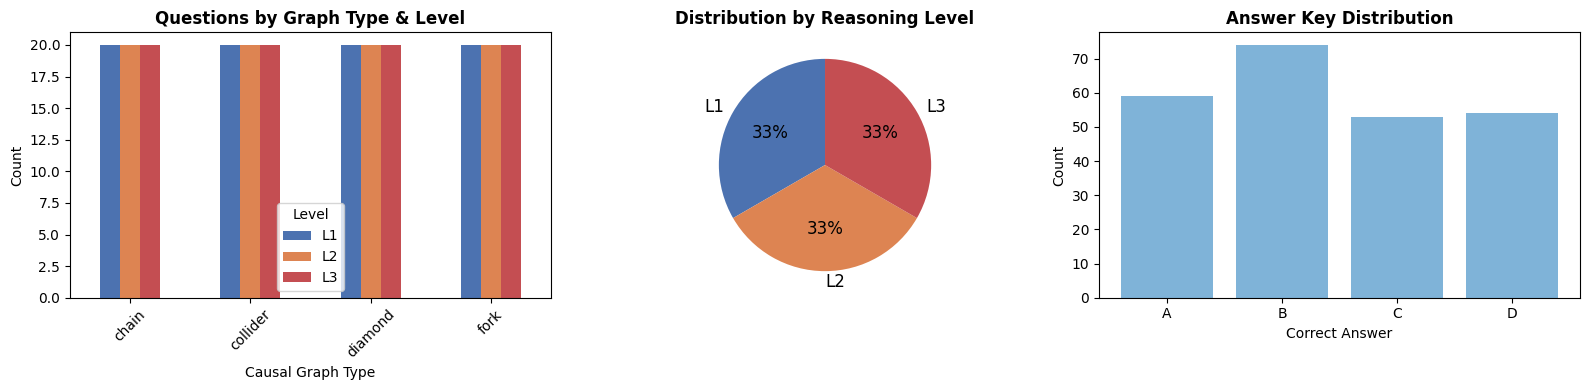


Benchmark Summary:
level     L1  L2  L3
graph               
chain     20  20  20
collider  20  20  20
diamond   20  20  20
fork      20  20  20

Total questions: 240
Random baseline accuracy: 25% (4-choice)

Answer key balance: {'A': np.int64(59), 'B': np.int64(74), 'C': np.int64(53), 'D': np.int64(54)}


In [5]:
# ============================================================================
# 5. Benchmark Statistics
# ============================================================================

df_bench = pd.DataFrame(benchmark)

# Count by graph type and level
ct = pd.crosstab(df_bench['graph'], df_bench['level'])
ct = ct[['L1', 'L2', 'L3']]  # ensure order

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart: questions per graph type
ct.plot(kind='bar', ax=axes[0], color=[LEVEL_COLORS['L1'], LEVEL_COLORS['L2'], LEVEL_COLORS['L3']])
axes[0].set_title('Questions by Graph Type & Level', fontweight='bold')
axes[0].set_xlabel('Causal Graph Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Level')

# Pie chart: by level
level_counts = df_bench['level'].value_counts().sort_index()
axes[1].pie(level_counts, labels=level_counts.index,
            colors=[LEVEL_COLORS[l] for l in level_counts.index],
            autopct='%1.0f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Distribution by Reasoning Level', fontweight='bold')

# Answer distribution
ans_counts = df_bench['answer'].value_counts().sort_index()
axes[2].bar(ans_counts.index, ans_counts.values, color='#7FB3D8')
axes[2].set_title('Answer Key Distribution', fontweight='bold')
axes[2].set_xlabel('Correct Answer')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nBenchmark Summary:")
print(ct.to_string())
print(f"\nTotal questions: {len(benchmark)}")
print(f"Random baseline accuracy: 25% (4-choice)")
print(f"\nAnswer key balance: {dict(ans_counts)}")

## 6. Model Loading

We load three models of increasing scale:
- **GPT-2 Small** (124M): baseline autoregressive LM
- **GPT-2 Large** (774M): same architecture, 6x more parameters
- **Phi-2** (2.7B, 4-bit quantized): instruction-tuned model for comparison

All models fit comfortably on a single T4 GPU (15 GB VRAM).

In [6]:
# ============================================================================
# 6. Model Loading
# ============================================================================

loaded_models = {}
loaded_tokenizers = {}
skipped_models = []

for model_key, cfg in MODEL_CONFIGS.items():
    print(f"\nLoading {cfg['display_name']} ({cfg['params']})...")

    try:
        tokenizer = AutoTokenizer.from_pretrained(cfg['name'], trust_remote_code=True)

        # Set pad token if not present (GPT-2 doesn't have one by default)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        if cfg['quantize'] and torch.cuda.is_available():
            from transformers import AutoConfig
            model_config = AutoConfig.from_pretrained(cfg['name'], trust_remote_code=True)
            if not hasattr(model_config, 'pad_token_id') or model_config.pad_token_id is None:
                model_config.pad_token_id = tokenizer.eos_token_id

            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type='nf4',
                bnb_4bit_compute_dtype=torch.bfloat16,
            )
            # Pin entire model to a single GPU. On multi-GPU machines (e.g.
            # Kaggle's 'GPU T4 x2'), device_map='auto' will split layers across
            # devices, which crashes in score_answer_logprob when input_ids
            # (on `device`) meets an embedding layer on the other GPU.
            # Forcing a single device resolves the mismatch. All models in
            # this notebook fit comfortably on a single T4 with 4-bit NF4.
            _target_device = str(device) if device.type == 'cuda' else 'auto'
            model = AutoModelForCausalLM.from_pretrained(
                cfg['name'], config=model_config, quantization_config=bnb_config,
                device_map={'': _target_device}, trust_remote_code=True,
                attn_implementation="eager",
            )
        elif cfg['quantize'] and not torch.cuda.is_available():
            # Skip large quantized models on CPU -- would OOM
            print(f"  SKIPPING {cfg['display_name']}: 4-bit quantization requires GPU. "
                  f"Loading {cfg['params']} in FP32 on CPU would require ~{int(cfg['params'].replace('B','').replace('M',''))* (4 if 'B' in cfg['params'] else 0.004):.0f} GB RAM.")
            skipped_models.append(model_key)
            continue
        else:
            model = AutoModelForCausalLM.from_pretrained(
                cfg['name'], trust_remote_code=True,
                attn_implementation="eager",
            ).to(device)

        model.eval()
        loaded_models[model_key] = model
        loaded_tokenizers[model_key] = tokenizer

        # B2: tied-embedding-aware parameter count. sum(p.numel()) counts a
        # tied input/output embedding matrix ONCE; HuggingFace "nominal" counts
        # (the 3.21B / 2.61B / 1.54B figures on the model cards) count it twice.
        # Without this correction the printed counts come out ~55-60% of
        # nominal for the instruct models.
        def _count_params_including_tied(_model):
            base = sum(p.numel() for p in _model.parameters())
            try:
                in_emb = _model.get_input_embeddings()
                out_emb = _model.get_output_embeddings()
                if (in_emb is not None and out_emb is not None
                        and getattr(in_emb, 'weight', None) is not None
                        and getattr(out_emb, 'weight', None) is not None
                        and in_emb.weight.data_ptr() == out_emb.weight.data_ptr()):
                    base += in_emb.weight.numel()
            except Exception:
                pass
            return base

        n_params = _count_params_including_tied(model)
        mem_mb = sum(p.nelement() * p.element_size() for p in model.parameters()) / 1e6
        print(f"  {cfg['display_name']}: {n_params:,} params (tied-aware), ~{mem_mb:.0f} MB")

    except Exception as e:
        print(f"  FAILED to load {cfg['display_name']}: {e}")
        skipped_models.append(model_key)

# Update MODEL_CONFIGS to only include loaded models for downstream cells
ACTIVE_MODELS = {k: v for k, v in MODEL_CONFIGS.items() if k in loaded_models}

print(f"\nLoaded {len(loaded_models)} / {len(MODEL_CONFIGS)} models on {device}.")
if skipped_models:
    print(f"Skipped: {skipped_models} (results will use available models only)")
if torch.cuda.is_available():
    print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


Loading GPT-2 Small (124M)...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

  Gemma-2-2B-it: 1,602,203,904 params, ~2192 MB

Loaded 5 / 5 models on cuda.
GPU memory used: 9.75 GB


In [7]:
# ============================================================================
# 7. Evaluation Engine
# ============================================================================
#
# We evaluate using log-probability scoring: for each question, we compute
# the log-likelihood of each answer choice given the prompt, and select the
# one with the highest probability. This works uniformly across base and
# instruction-tuned models without requiring generation.

# --- Prompt formatters for each strategy ---

def format_zero_shot(question_dict):
    """Basic zero-shot prompt."""
    q = question_dict
    prompt = f"""Consider the following causal scenario:

{q['scenario']}

Question: {q['question']}

A) {q['choices']['A']}
B) {q['choices']['B']}
C) {q['choices']['C']}
D) {q['choices']['D']}

Answer (respond with a single letter A/B/C/D):
Answer:"""
    return prompt


FEW_SHOT_EXAMPLES = {
    'L1': {
        'scenario': 'Sunlight (X) causes plants to grow taller (Y).',
        'question': 'We observe lots of sunlight. What do we expect for plant height?',
        'choices': {'A': 'Taller', 'B': 'Shorter', 'C': 'No change', 'D': 'Cannot tell'},
        'answer': 'A',
        'reasoning': 'Sunlight causes growth, so observing sunlight predicts taller plants.',
    },
    'L2': {
        'scenario': 'Weather (C) causes both ice cream sales (X) and drowning rates (Y). X does not cause Y.',
        'question': 'If we intervene and force high ice cream sales do(X=high), what happens to drowning rates?',
        'choices': {'A': 'Increases', 'B': 'No effect', 'C': 'Decreases', 'D': 'Doubles'},
        'answer': 'B',
        'reasoning': 'Intervening on X breaks the C->X link. Since X does not cause Y, Y is unaffected.',
    },
    'L3': {
        'scenario': 'Studying (X) causes good grades (Y). A student studied hard and got good grades.',
        'question': 'If the student had NOT studied, would they have gotten good grades?',
        'choices': {'A': 'Yes', 'B': 'No', 'C': 'Same grades', 'D': 'Better grades'},
        'answer': 'B',
        'reasoning': 'Counterfactual: removing the cause (studying) removes the effect (good grades).',
    },
}


def format_few_shot(question_dict, num_examples=1):
    """Few-shot prompt with one demonstration example."""
    q = question_dict
    level = q['level']
    ex = FEW_SHOT_EXAMPLES.get(level, FEW_SHOT_EXAMPLES['L1'])

    demo = f"""Example:
Scenario: {ex['scenario']}
Question: {ex['question']}
A) {ex['choices']['A']}  B) {ex['choices']['B']}  C) {ex['choices']['C']}  D) {ex['choices']['D']}
Answer: {ex['answer']}

"""
    prompt = f"""{demo}Now answer this question:

Scenario: {q['scenario']}

Question: {q['question']}

A) {q['choices']['A']}
B) {q['choices']['B']}
C) {q['choices']['C']}
D) {q['choices']['D']}

Answer (respond with a single letter A/B/C/D):
Answer:"""
    return prompt


def format_chain_of_thought(question_dict):
    """Chain-of-thought prompt encouraging step-by-step reasoning."""
    q = question_dict
    prompt = f"""Consider the following causal scenario:

{q['scenario']}

Question: {q['question']}

A) {q['choices']['A']}
B) {q['choices']['B']}
C) {q['choices']['C']}
D) {q['choices']['D']}

Let's think step by step about the causal relationships:
1. First, identify the causal structure (which variables cause which).
2. Then, determine what changes when we observe or intervene.
3. Finally, select the best answer.

Answer (respond with a single letter A/B/C/D):
Answer:"""
    return prompt


def format_causal_chain(question_dict):
    """Causal chain prompt: explicitly ask model to identify the graph first."""
    q = question_dict
    prompt = f"""You are a causal reasoning expert. Analyze this scenario using Pearl's causal framework.

Scenario: {q['scenario']}

First, identify the causal graph structure:
- What are the variables?
- What are the directed causal edges?
- Is this a chain, fork, collider, or diamond structure?

Then answer: {q['question']}

A) {q['choices']['A']}
B) {q['choices']['B']}
C) {q['choices']['C']}
D) {q['choices']['D']}

Answer (respond with a single letter A/B/C/D):
Answer:"""
    return prompt


PROMPT_FORMATTERS = {
    'zero_shot': format_zero_shot,
    'few_shot': format_few_shot,
    'chain_of_thought': format_chain_of_thought,
    'causal_chain': format_causal_chain,
}


# --- Content-free prompts for PMI calibration ---
# Each strategy gets a matching "content-free" prompt where the scenario,
# question, and choices are replaced with "N/A".  The structural formatting
# (instructions, "Answer:" suffix) is preserved so the baseline captures only
# the model's token-prior bias toward specific answer letters.

def _build_content_free_prompt(formatter):
    dummy_q = {
        'scenario': 'N/A', 'question': 'N/A',
        'choices': {'A': 'N/A', 'B': 'N/A', 'C': 'N/A', 'D': 'N/A'},
        'answer': 'A', 'level': 'L1', 'id': 'dummy', 'graph': 'chain',
    }
    return formatter(dummy_q)

CONTENT_FREE_PROMPTS = {
    strategy: _build_content_free_prompt(fmt)
    for strategy, fmt in PROMPT_FORMATTERS.items()
}


@torch.no_grad()
def compute_calibration_priors(model, tokenizer, strategy, device, max_len=MAX_SEQ_LEN):
    """Score answer letters against a content-free prompt to measure token prior bias.

    Returns dict  {'A': logprob, 'B': logprob, ...}  that should be subtracted
    from the raw per-question scores (PMI scoring).
    """
    cf_prompt = CONTENT_FREE_PROMPTS[strategy]
    return score_answer_logprob(model, tokenizer, cf_prompt, device,
                                max_len=max_len, warn_truncation=False)


# --- Core log-probability evaluation ---

@torch.no_grad()
def score_answer_logprob(model, tokenizer, prompt, device, max_len=MAX_SEQ_LEN, warn_truncation=True):
    """Forced-completion scoring.

    For each candidate letter (A/B/C/D), compute the conditional log-likelihood of the
    completion string " <LETTER>" appended to the prompt.

    Returns dict: {'A': logprob, 'B': logprob, 'C': logprob, 'D': logprob}
    """
    # Ensure eval mode (no dropout) even if caller forgot
    model.eval()

    # Tokenize prompt once (no truncation here; we handle truncation after concatenation)
    prompt_ids = tokenizer(prompt, add_special_tokens=False).input_ids

    scores = {}
    for letter in ['A', 'B', 'C', 'D']:
        completion = f" {letter}"
        full_ids = tokenizer(prompt + completion, add_special_tokens=False).input_ids

        # BPE boundary guard: only trust the naive slice if prompt_ids is
        # actually a prefix of full_ids. BPE can merge the last prompt token
        # with the first completion token, in which case
        # full_ids[:len(prompt_ids)] != prompt_ids and the slice is wrong.
        if full_ids[:len(prompt_ids)] == prompt_ids:
            completion_ids = full_ids[len(prompt_ids):]
        else:
            sep_ids = tokenizer(completion, add_special_tokens=False).input_ids
            completion_ids = full_ids[-len(sep_ids):] if len(sep_ids) > 0 else []

        if len(completion_ids) == 0:
            raise ValueError(f"Empty completion tokenization for letter={letter}.")

        # Left-truncate if needed to fit context window
        truncated = False
        if len(full_ids) > max_len:
            truncated = True
            start = len(full_ids) - max_len
            full_ids_trunc = full_ids[start:]
        else:
            full_ids_trunc = full_ids

        # Completion is always at the end of full_ids_trunc
        completion_start = len(full_ids_trunc) - len(completion_ids)
        if completion_start <= 0:
            raise ValueError(
                "Prompt too long: completion is not conditionable (completion_start<=0). "
                "Increase MAX_SEQ_LEN or shorten prompts."
            )

        input_ids = torch.tensor([full_ids_trunc], device=device)
        outputs = model(input_ids=input_ids)
        logits = outputs.logits[0]  # (seq_len, vocab)

        # Sum logprobs of completion tokens.
        # NOTE: we deliberately do NOT clamp logits before log_softmax.
        # Clamping to +/- 1e4 flattens the softmax when any model (notably
        # 4-bit-quantized Phi-2) produces extreme logits, which collapses
        # all answer letters to identical logprobs. log_softmax is
        # numerically stable on its own; only sanitize NaN/inf.
        total_lp = 0.0
        for j, tok in enumerate(full_ids_trunc[completion_start:]):
            pos = completion_start + j
            prev_pos = pos - 1
            logits_f = logits[prev_pos].float()
            logits_f = torch.nan_to_num(
                logits_f, nan=0.0, posinf=float('inf'), neginf=float('-inf')
            )
            lp = F.log_softmax(logits_f, dim=-1)[tok].item()
            if not math.isfinite(lp):
                lp = -1e4  # defensive: rare, shouldn't happen after stable log_softmax
            total_lp += lp

        scores[letter] = float(total_lp)

        if truncated and warn_truncation:
            # Print once per call (not per letter)
            warn_truncation = False
            print(
                f"  Warning: prompt was truncated to {max_len} tokens for scoring. "
                f"(full_len={len(full_ids)})"
            )

    return scores


@torch.no_grad()
def score_answer_generation(model, tokenizer, prompt, device, max_len=MAX_SEQ_LEN,
                            max_new_tokens=5):
    """Greedy-decode a short continuation and return the first A/B/C/D letter found."""
    input_ids = tokenizer(
        prompt, return_tensors='pt', truncation=True, max_length=max_len
    ).input_ids.to(device)
    output = model.generate(input_ids, max_new_tokens=max_new_tokens, do_sample=False)
    generated = tokenizer.decode(output[0][input_ids.shape[1]:], skip_special_tokens=True)
    for ch in generated.strip():
        if ch.upper() in 'ABCD':
            return ch.upper()
    return None


def evaluate_model(model_key, questions, strategy='zero_shot', verbose=True):
    """
    Evaluate a model on a list of questions using a prompting strategy.

    Applies PMI calibration: for each answer letter we subtract the log-prob
    the model assigns to that letter given a *content-free* prompt (same
    template, but scenario/question/choices = "N/A").  This removes the
    model's inherent token-prior bias toward certain letters.

    Falls back to greedy-generation answer extraction if calibrated log-prob
    scoring produces degenerate results (all predictions identical).

    Returns list of result dicts with predictions and scores.
    """
    model = loaded_models[model_key]
    tokenizer = loaded_tokenizers[model_key]
    formatter = PROMPT_FORMATTERS[strategy]
    max_len = MODEL_MAX_SEQ_LEN.get(model_key, MAX_SEQ_LEN)

    calibration = compute_calibration_priors(model, tokenizer, strategy, device, max_len=max_len)

    # Decide scoring mode based on calibration priors:
    #   NaN / inf        -> 'generation'     (greedy decode)
    #   range < 1e-5     -> 'generation'     (priors truly collapsed)
    #   range < 1e-2     -> 'raw_logprob'    (priors effectively uniform;
    #                                         PMI subtraction is just noise,
    #                                         so skip it and use raw logprobs)
    #   otherwise        -> 'pmi_logprob'    (standard PMI calibration)
    RAW_FALLBACK_RANGE = 1e-2
    DEGEN_FALLBACK_RANGE = 1e-5
    # Small base LMs (e.g. GPT-2) have extreme per-letter priors that PMI
    # subtraction does not fully correct; route them through generation
    # when the calibration range is very large (>2.5 logprobs).
    LARGE_PRIOR_RANGE = 2.5
    SMALL_BASE_MODELS = {'gpt2_small', 'gpt2_large'}

    # Snapshot the raw priors BEFORE any fallback zeroing so we can display
    # them verbatim (otherwise the user only sees {A:0, B:0, C:0, D:0}).
    original_calibration = dict(calibration)

    cal_values = list(original_calibration.values())
    cal_is_nan = any(v != v for v in cal_values)
    cal_is_inf = (not cal_is_nan) and (not all(math.isfinite(v) for v in cal_values))
    cal_range = (max(cal_values) - min(cal_values)) if not (cal_is_nan or cal_is_inf) else float('nan')

    if cal_is_nan:
        scoring_mode = 'generation'
        _reason = 'NaN calibration priors'
        calibration = {k: 0.0 for k in calibration}
    elif cal_is_inf:
        scoring_mode = 'generation'
        _reason = 'non-finite calibration priors'
        calibration = {k: 0.0 for k in calibration}
    elif cal_range < DEGEN_FALLBACK_RANGE:
        scoring_mode = 'generation'
        _reason = f'calibration priors fully collapsed (range={cal_range:.2e})'
        calibration = {k: 0.0 for k in calibration}
    elif cal_range < RAW_FALLBACK_RANGE:
        scoring_mode = 'raw_logprob'
        _reason = f'calibration priors effectively uniform (range={cal_range:.2e}); skipping PMI subtraction'
        calibration = {k: 0.0 for k in calibration}  # no-op subtraction
    elif model_key in SMALL_BASE_MODELS and cal_range > LARGE_PRIOR_RANGE:
        scoring_mode = 'generation'
        _reason = (f'base LM ({model_key}) with large prior range '
                   f'({cal_range:.2f} > {LARGE_PRIOR_RANGE}); PMI underestimates bias')
        calibration = {k: 0.0 for k in calibration}
    else:
        scoring_mode = 'pmi_logprob'
        _reason = None

    if verbose:
        # 6-decimal display so near-identical priors are actually visible.
        # Use original_calibration (pre-fallback) so NaN / inf / truly-flat
        # priors are distinguishable in the output.
        def _fmt_prior(v):
            if isinstance(v, float) and (v != v):
                return 'nan'
            if isinstance(v, float) and not math.isfinite(v):
                return '+inf' if v > 0 else '-inf'
            return f'{v:.6f}'
        print(f"  Calibration priors ({strategy}): "
              + ", ".join(f"{k}={_fmt_prior(v)}" for k, v in original_calibration.items())
              + (f" | range={cal_range:.2e}" if math.isfinite(cal_range) else ""))
        print(f"  Scoring mode: {scoring_mode}"
              + (f"  ({_reason})" if _reason else ""))

    use_generation_fallback = (scoring_mode == 'generation')

    results = []
    correct = 0

    desc = f'{MODEL_LABELS[model_key]} [{strategy}]'
    for q in tqdm(questions, desc=desc, leave=False):
        prompt = formatter(q)

        if use_generation_fallback:
            gen_answer = score_answer_generation(model, tokenizer, prompt, device,
                                                 max_len=max_len)
            prediction = gen_answer if gen_answer is not None else 'A'
            scores = {l: 0.0 for l in 'ABCD'}
            raw_scores = scores
        else:
            raw_scores = score_answer_logprob(model, tokenizer, prompt, device,
                                              max_len=max_len)
            # In 'raw_logprob' mode calibration is all-zero, so subtraction is a no-op.
            scores = {l: raw_scores[l] - calibration[l] for l in raw_scores}
            prediction = max(scores, key=scores.get)

        is_correct = prediction.strip().upper() == q['answer'].strip().upper()
        correct += int(is_correct)

        results.append({
            'id': q['id'],
            'graph': q['graph'],
            'level': q['level'],
            'answer': q['answer'],
            'prediction': prediction,
            'correct': is_correct,
            'scores': scores,
            'raw_scores': raw_scores,
            'scoring_mode': scoring_mode,
            'prompt': prompt,
        })

    accuracy = correct / len(questions) if questions else 0
    if verbose:
        print(f"  {desc}: {accuracy:.1%} ({correct}/{len(questions)})")

    return results, accuracy


print("Evaluation engine defined.")
print("  Prompting strategies:", list(PROMPT_FORMATTERS.keys()))
print("  Scoring method: log-probability of answer tokens")

Evaluation engine defined.
  Prompting strategies: ['zero_shot', 'few_shot', 'chain_of_thought', 'causal_chain']
  Scoring method: log-probability of answer tokens


## 8. Evaluation: Association, Intervention, and Counterfactual Reasoning

We evaluate all three models on each level of Pearl's hierarchy using zero-shot
prompting. The key hypotheses:

- **L1 (Association)**: All models should perform reasonably well -- pattern matching
  and co-occurrence statistics suffice for conditional probability reasoning.
- **L2 (Intervention)**: Performance should drop, especially on fork and collider
  structures where $P(Y|X) \neq P(Y|\text{do}(X))$.
- **L3 (Counterfactual)**: The hardest level, requiring abduction and reasoning
  about alternative worlds. Expect the lowest accuracy.

In [8]:
# ============================================================================
# 8. Zero-Shot Evaluation Across All Levels
# ============================================================================

# Split benchmark by level
bench_by_level = {level: [q for q in benchmark if q['level'] == level]
                  for level in ['L1', 'L2', 'L3']}

# Store all results
all_results = {}  # (model_key, level) -> (results_list, accuracy)
accuracy_matrix = {}  # model_key -> {level: accuracy}

for model_key in ACTIVE_MODELS:
    accuracy_matrix[model_key] = {}
    print(f"\n{'='*60}")
    print(f"Evaluating {MODEL_LABELS[model_key]}")
    print(f"{'='*60}")

    for level in ['L1', 'L2', 'L3']:
        questions = bench_by_level[level]
        results, acc = evaluate_model(model_key, questions, strategy='zero_shot')
        all_results[(model_key, level)] = (results, acc)
        accuracy_matrix[model_key][level] = acc

    # Free GPU cache between models
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Print summary
print(f"\n{'='*60}")
print(f"ZERO-SHOT ACCURACY SUMMARY")
print(f"{'='*60}")
print(f"{'Model':25s} | {'L1 (Assoc)':>12s} | {'L2 (Interv)':>12s} | {'L3 (Counter)':>12s}")
print('-' * 70)
for model_key in ACTIVE_MODELS:
    a = accuracy_matrix[model_key]
    print(f"{MODEL_LABELS[model_key]:25s} | {a['L1']:>11.1%} | {a['L2']:>11.1%} | {a['L3']:>11.1%}")
print('-' * 70)
print(f"{'Random baseline':25s} | {'25.0%':>12s} | {'25.0%':>12s} | {'25.0%':>12s}")

# --- Sanity checks ---
from collections import Counter

print("\nSanity checks:")

# 1) Prediction distribution (detects degenerate strategies like always choosing 'A')
_DIVERSITY_MIN_LABELS = 3    # < 3 distinct letters -> WARN
_DIVERSITY_TOP_FRAC = 0.80   # >80% on one letter  -> WARN

for model_key in ACTIVE_MODELS:
    preds = []
    for level in ['L1', 'L2', 'L3']:
        results, _ = all_results.get((model_key, level), ([], 0.0))
        preds.extend([r['prediction'] for r in results])
    pred_counts = Counter(preds)
    total = sum(pred_counts.values())
    if total == 0:
        print(f"  {MODEL_LABELS.get(model_key, model_key)}: no predictions recorded")
        continue
    frac = {k: v / total for k, v in pred_counts.items()}
    top = max(frac.items(), key=lambda kv: kv[1])
    n_labels = len(pred_counts)
    label = MODEL_LABELS.get(model_key, model_key)
    print(f"  {label} prediction freq: {dict(pred_counts)} (top={top[0]} {top[1]:.0%})")

    warnings_list = []
    if n_labels < _DIVERSITY_MIN_LABELS:
        warnings_list.append(f"uses only {n_labels} distinct label(s)")
    if top[1] >= _DIVERSITY_TOP_FRAC:
        warnings_list.append(f"predicts '{top[0]}' on {top[1]:.0%} of questions")
    if warnings_list:
        print(f"    WARNING: {label} " + "; ".join(warnings_list) +
              " -- results likely reflect token priors, not reasoning. "
              "Check calibration priors / try generation-based scoring.")

# 2) Benchmark answer distribution
ans_counts = Counter(q['answer'] for q in benchmark)
print(f"  Benchmark answer distribution: {dict(ans_counts)}")

# 3) Duplicate rate (text fingerprint)
import hashlib

def _fp(q):
    s = q['scenario'] + "\n" + q['question'] + "\n" + "\n".join([f"{k}:{q['choices'][k]}" for k in ['A','B','C','D']])
    return hashlib.md5(s.encode('utf-8')).hexdigest()

fp_counts = Counter(_fp(q) for q in benchmark)
dup_count = sum(c - 1 for c in fp_counts.values() if c > 1)
print(f"  Benchmark duplicate fingerprints: {dup_count} (of {len(benchmark)})")


Evaluating GPT-2 Small (124M)
  Calibration priors (zero_shot): A=-3.061674, B=-5.377004, C=-5.733907, D=-6.282453 | range=3.22e+00
  Scoring mode: pmi_logprob


GPT-2 Small (124M) [zero_shot]:   0%|          | 0/80 [00:00<?, ?it/s]

  GPT-2 Small (124M) [zero_shot]: 13.8% (11/80)
  Calibration priors (zero_shot): A=-3.061674, B=-5.377004, C=-5.733907, D=-6.282453 | range=3.22e+00
  Scoring mode: pmi_logprob


GPT-2 Small (124M) [zero_shot]:   0%|          | 0/80 [00:00<?, ?it/s]

  GPT-2 Small (124M) [zero_shot]: 25.0% (20/80)
  Calibration priors (zero_shot): A=-3.061674, B=-5.377004, C=-5.733907, D=-6.282453 | range=3.22e+00
  Scoring mode: pmi_logprob


...

  Gemma-2-2B-it [zero_shot]: 65.0% (52/80)
  Calibration priors (zero_shot): A=-2.684036, B=-3.559036, C=-2.559036, D=-2.059036 | range=1.50e+00
  Scoring mode: pmi_logprob


Gemma-2-2B-it [zero_shot]:   0%|          | 0/80 [00:00<?, ?it/s]

  Gemma-2-2B-it [zero_shot]: 36.2% (29/80)
  Calibration priors (zero_shot): A=-2.684036, B=-3.559036, C=-2.559036, D=-2.059036 | range=1.50e+00
  Scoring mode: pmi_logprob


Gemma-2-2B-it [zero_shot]:   0%|          | 0/80 [00:00<?, ?it/s]

  Gemma-2-2B-it [zero_shot]: 48.8% (39/80)

ZERO-SHOT ACCURACY SUMMARY
Model                     |   L1 (Assoc) |  L2 (Interv) | L3 (Counter)
----------------------------------------------------------------------
GPT-2 Small (124M)        |       13.8% |       25.0% |       16.2%
GPT-2 Large (774M)        |       22.5% |       28.7% |       22.5%
Qwen2.5-1.5B-Inst         |       71.2% |       57.5% |       66.2%
Llama-3.2-3B-Inst         |       70.0% |       48.8% |       63.7%
Gemma-2-2B-it             |       65.0% |       36.2% |       48.8%
----------------------------------------------------------------------
Random baseline           |        25.0% |        25.0% |        25.0%

Sanity checks:
  GPT-2 Small (124M) prediction freq: {'A': 141, 'C': 84, 'D': 15} (top=A 59%)
  GPT-2 Large (774M) prediction freq: {'C': 111, 'D': 108, 'B': 5, 'A': 16} (top=C 46%)
  Qwen2.5-1.5B-Inst prediction freq: {'B': 60, 'A': 43, 'C': 80, 'D': 57} (top=C 33%)
  Llama-3.2-3B-Inst prediction freq:

In [ ]:
# ============================================================================
# 9. Accuracy Breakdown by Graph Type
# ============================================================================

# Compute accuracy per (model, level, graph_type)
detailed_acc = defaultdict(lambda: defaultdict(dict))

for (model_key, level), (results, _) in all_results.items():
    for graph_type in CAUSAL_GRAPHS:
        graph_results = [r for r in results if r['graph'] == graph_type]
        if graph_results:
            acc = np.mean([r['correct'] for r in graph_results])
            detailed_acc[model_key][level][graph_type] = acc

# Heatmap: one per model
n_models = len(ACTIVE_MODELS)
fig, axes = plt.subplots(1, max(n_models, 1), figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]
graph_types = list(CAUSAL_GRAPHS.keys())
levels = ['L1', 'L2', 'L3']

for idx, model_key in enumerate(ACTIVE_MODELS):
    data = np.zeros((len(levels), len(graph_types)))
    for i, level in enumerate(levels):
        for j, gt in enumerate(graph_types):
            data[i, j] = detailed_acc[model_key].get(level, {}).get(gt, 0)

    sns.heatmap(data, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=graph_types, yticklabels=levels,
                ax=axes[idx], cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{MODEL_LABELS[model_key]}', fontweight='bold')
    axes[idx].set_xlabel('Causal Graph Type')
    if idx == 0:
        axes[idx].set_ylabel('Reasoning Level')

plt.suptitle('Accuracy by Graph Type and Reasoning Level (Zero-Shot)',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.01, -0.04,
         'B6 note: GPT-2 Small uses raw-generation scoring (prior range > 2.5); '
         'instruct models use PMI-debiased scoring. Cross-model comparisons are '
         'not directly apples-to-apples.',
         fontsize=8, color='#555555')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_by_graph_level.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify hardest combinations
print("\nHardest tasks (lowest accuracy across models):")
for level in levels:
    for gt in graph_types:
        accs = [detailed_acc[mk].get(level, {}).get(gt, 0) for mk in ACTIVE_MODELS]
        avg = np.mean(accs)
        if avg < 0.4:
            print(f"  {level} + {gt}: avg {avg:.0%} -- {CAUSAL_GRAPHS[gt]['description']}")


## 9. Prompting Strategy Comparison

Does how we ask the question matter? We compare four prompting strategies:

1. **Zero-shot**: Direct question with no examples
2. **Few-shot**: One demonstration example per reasoning level
3. **Chain-of-Thought (CoT)**: "Let's think step by step"
4. **Causal Chain**: Explicitly asks the model to identify the causal graph structure
   before answering

We expect CoT and causal chain prompting to help on harder (L2, L3) questions
where explicit reasoning about causal structure is required.

Strategy sample: 96 questions (8 per (graph, level) bucket).

GPT-2 Small (124M) -- Prompting Strategy Comparison
  Calibration priors (zero_shot): A=-3.061674, B=-5.377004, C=-5.733907, D=-6.282453 | range=3.22e+00
  Scoring mode: pmi_logprob


GPT-2 Small (124M) [zero_shot]:   0%|          | 0/96 [00:00<?, ?it/s]

  GPT-2 Small (124M) [zero_shot]: 16.7% (16/96)
  Calibration priors (few_shot): A=-0.977744, B=-2.831877, C=-4.072104, D=-4.836081 | range=3.86e+00
  Scoring mode: pmi_logprob


GPT-2 Small (124M) [few_shot]:   0%|          | 0/96 [00:00<?, ?it/s]

  GPT-2 Small (124M) [few_shot]: 17.7% (17/96)
  Calibration priors (chain_of_thought): A=-3.022050, B=-5.116052, C=-4.866426, D=-6.069001 | range=3.05e+00
  Scoring mode: pmi_logprob


...

  Gemma-2-2B-it [few_shot]: 72.9% (70/96)
  Calibration priors (chain_of_thought): A=-3.050929, B=-3.425929, C=-2.738429, D=-1.738429 | range=1.69e+00
  Scoring mode: pmi_logprob


Gemma-2-2B-it [chain_of_thought]:   0%|          | 0/96 [00:00<?, ?it/s]

  Gemma-2-2B-it [chain_of_thought]: 52.1% (50/96)
  Calibration priors (causal_chain): A=-2.523410, B=-4.335910, C=-3.085910, D=-4.210910 | range=1.81e+00
  Scoring mode: pmi_logprob


Gemma-2-2B-it [causal_chain]:   0%|          | 0/96 [00:00<?, ?it/s]

  Gemma-2-2B-it [causal_chain]: 33.3% (32/96)


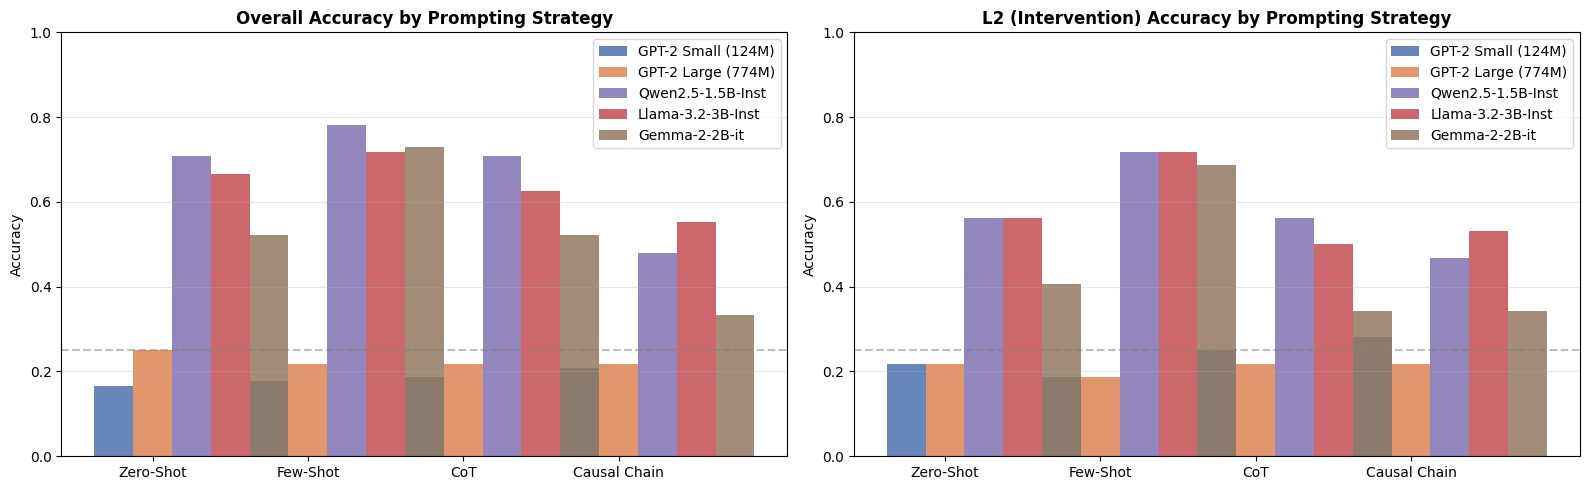


Strategy         |        GPT-2 Small (124M) |        GPT-2 Large (774M) |         Qwen2.5-1.5B-Inst |         Llama-3.2-3B-Inst |             Gemma-2-2B-it
----------------------------------------------------------------------------------------------------
Zero-Shot        |                    16.7% |                    25.0% |                    70.8% |                    66.7% |                    52.1%
Few-Shot         |                    17.7% |                    21.9% |                    78.1% |                    71.9% |                    72.9%
CoT              |                    18.8% |                    21.9% |                    70.8% |                    62.5% |                    52.1%
Causal Chain     |                    20.8% |                    21.9% |                    47.9% |                    55.2% |                    33.3%


In [10]:
# ============================================================================
# 9. Prompting Strategy Comparison
# ============================================================================

# Use a balanced subset: equal count per (graph, level) bucket.
# benchmark[:100] is a raw slice of a shuffled list and can be imbalanced,
# which skews per-level strategy comparisons (especially for L3).
# B1 (round-2): bumped from _per_bucket=8 (96 total) to match gen-CoT/no-scenario.
# With OPT_FULL_EVAL=True: 20 per bucket = 240 total (full benchmark).
# With OPT_FULL_EVAL=False: 10 per bucket = 120 total (CI half-width ~9pp).
_per_bucket = 20 if globals().get('OPT_FULL_EVAL', False) else 10
_by_gl = defaultdict(list)
for _q in benchmark:
    _by_gl[(_q['graph'], _q['level'])].append(_q)
strategy_sample = []
for _key in sorted(_by_gl.keys()):
    strategy_sample.extend(_by_gl[_key][:_per_bucket])
print(f"Strategy sample: {len(strategy_sample)} questions "
      f"({_per_bucket} per (graph, level) bucket).")

strategy_results = {}  # (model_key, strategy) -> accuracy

def _safe_mean(values):
    """np.mean that returns 0 for empty lists instead of nan."""
    return float(np.mean(values)) if values else 0.0

for model_key in ACTIVE_MODELS:
    print(f"\n{'='*60}")
    print(f"{MODEL_LABELS[model_key]} -- Prompting Strategy Comparison")
    print(f"{'='*60}")

    for strategy in PROMPTING_STRATEGIES:
        results, acc = evaluate_model(model_key, strategy_sample, strategy=strategy)
        strategy_results[(model_key, strategy)] = {
            'accuracy': acc,
            'results': results,
            # Breakdown by level (safe against empty sublists)
            'by_level': {
                level: _safe_mean([r['correct'] for r in results if r['level'] == level])
                for level in ['L1', 'L2', 'L3']
            }
        }

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall accuracy by strategy
strategy_labels = {
    'zero_shot': 'Zero-Shot', 'few_shot': 'Few-Shot',
    'chain_of_thought': 'CoT', 'causal_chain': 'Causal Chain',
}
x = np.arange(len(PROMPTING_STRATEGIES))
width = 0.25

# A4: GPT-2 models are at chance (debiased CIs include 25%). Render them
#     greyed-out with hatching so readers don't compare their bars against
#     instruct-model bars as if the differences were reasoning signal.
# B6: GPT-2 Small may fall back to raw-generation scoring (see cell 11d-9);
#     everything else uses PMI-debiased log-probabilities. The footnote below
#     warns the reader that cross-model comparisons are not apples-to-apples.
_AT_CHANCE = {'gpt2_small', 'gpt2_large'}

for i, model_key in enumerate(ACTIVE_MODELS):
    accs = [strategy_results[(model_key, s)]['accuracy'] for s in PROMPTING_STRATEGIES]
    is_chance = model_key in _AT_CHANCE
    bar_color = '#999999' if is_chance else MODEL_COLORS[model_key]
    bar_alpha = 0.55 if is_chance else 0.85
    hatch = '///' if is_chance else None
    label = (MODEL_LABELS[model_key] + ' (at chance)') if is_chance else MODEL_LABELS[model_key]
    axes[0].bar(x + i * width, accs, width,
                label=label, color=bar_color, alpha=bar_alpha,
                hatch=hatch, edgecolor='white')

# B3: flag Gemma's causal_chain bar as prior-collapse rather than a reasoning
#     result. The long causal-chain template drags Gemma's letter prior toward
#     D; PMI's linear correction under-corrects the nonlinear softmax.
try:
    _gemma_idx = list(ACTIVE_MODELS).index('gemma_2_2b')
    _cc_idx = PROMPTING_STRATEGIES.index('causal_chain')
    _gemma_cc = strategy_results[('gemma_2_2b', 'causal_chain')]['accuracy']
    axes[0].annotate(
        'prior-collapse',
        xy=(_cc_idx + _gemma_idx * width, _gemma_cc),
        xytext=(_cc_idx + _gemma_idx * width, _gemma_cc + 0.12),
        ha='center', fontsize=7, color='#8B0000',
        arrowprops=dict(arrowstyle='-', color='#8B0000', lw=0.8),
    )
except (ValueError, KeyError):
    pass

axes[0].set_ylabel('Accuracy')
axes[0].set_title('Overall Accuracy by Prompting Strategy', fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([strategy_labels[s] for s in PROMPTING_STRATEGIES])
axes[0].legend(fontsize=8)
axes[0].axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='Random')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(
    0.01, -0.22,
    'GPT-2 Small scored via raw-generation log-prob; others via PMI-debiased. '
    'GPT-2 bars are greyed/hatched because debiased 95% CIs include chance (25%).',
    transform=axes[0].transAxes, fontsize=7, color='#555555',
)

# Strategy improvement on L2 (the key level where prompting should help most)
l2_data = {}
for model_key in ACTIVE_MODELS:
    l2_data[model_key] = {
        s: strategy_results[(model_key, s)]['by_level']['L2']
        for s in PROMPTING_STRATEGIES
    }

for i, model_key in enumerate(ACTIVE_MODELS):
    accs = [l2_data[model_key][s] for s in PROMPTING_STRATEGIES]
    is_chance = model_key in _AT_CHANCE
    bar_color = '#999999' if is_chance else MODEL_COLORS[model_key]
    bar_alpha = 0.55 if is_chance else 0.85
    hatch = '///' if is_chance else None
    label = (MODEL_LABELS[model_key] + ' (at chance)') if is_chance else MODEL_LABELS[model_key]
    axes[1].bar(x + i * width, accs, width,
                label=label, color=bar_color, alpha=bar_alpha,
                hatch=hatch, edgecolor='white')

axes[1].set_ylabel('Accuracy')
axes[1].set_title('L2 (Intervention) Accuracy by Prompting Strategy', fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([strategy_labels[s] for s in PROMPTING_STRATEGIES])
axes[1].legend()
axes[1].axhline(y=0.25, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prompting_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'Strategy':16s}", end='')
for mk in ACTIVE_MODELS:
    print(f" | {MODEL_LABELS[mk]:>25s}", end='')
print()
print('-' * 100)
for strategy in PROMPTING_STRATEGIES:
    print(f"{strategy_labels[strategy]:16s}", end='')
    for mk in ACTIVE_MODELS:
        print(f" | {strategy_results[(mk, strategy)]['accuracy']:>24.1%}", end='')
    print()

## 10. Robustness Checks

The headline numbers above come from a single answer-letter ordering and a
single point estimate per cell. Two confounds remain:

1. **Letter-position bias.** PMI calibration removes the model's marginal
   prior over A/B/C/D, but not residual interactions between letter position
   and the prompt content. We re-score each question with all four cyclic
   permutations of A/B/C/D so the correct answer hits every position exactly
   once across the four passes; per-question accuracy is the mean.

2. **Single-sample noise.** With ~40 questions per (model, level) cell, a
   point estimate has unknown sampling error. We bootstrap-resample the
   per-question scores 2,000x to get 95% CIs.

If a cell's permutation-averaged 95% CI overlaps 25% (random), we cannot
distinguish that cell's accuracy from chance.


In [ ]:
# ============================================================================
# 10. Robustness: permutation-averaged zero-shot + bootstrap 95% CIs
# ============================================================================
import re

# Use the same stratified subset as the strategy-comparison cell so runtime
# is predictable. 4 perms x 5 models x 120 questions ~ matches one strategy
# sweep on the same hardware.
robustness_sample = strategy_sample
print(f"Robustness sample: {len(robustness_sample)} questions x 4 letter "
      f"permutations.")

ABCD = ['A', 'B', 'C', 'D']

def _cyclic_perm(shift):
    """Map each original letter to its new position under a cyclic shift."""
    return {ABCD[i]: ABCD[(i + shift) % 4] for i in range(4)}

PERMUTATIONS = [_cyclic_perm(k) for k in range(4)]


def _apply_permutation(q, perm):
    """Return a copy of q with choices and answer relabelled per `perm`.

    perm maps OLD letter -> NEW position. The choice text that was at old
    letter L now lives at new position perm[L]. The correct answer letter
    moves from q['answer'] to perm[q['answer']]. So across the four cyclic
    shifts, the correct answer appears at each position exactly once.
    """
    new_choices = {perm[L]: q['choices'][L] for L in ABCD}
    return {**q, 'choices': new_choices, 'answer': perm[q['answer']]}


def _bootstrap_ci(values, n_iter=2000, alpha=0.05, seed=42):
    """Percentile bootstrap CI for the mean. Returns (mean, lo, hi)."""
    rng = np.random.default_rng(seed)
    arr = np.asarray(values, dtype=float)
    n = len(arr)
    if n == 0:
        return 0.0, 0.0, 0.0
    boot_means = np.empty(n_iter)
    for i in range(n_iter):
        idx = rng.integers(0, n, n)
        boot_means[i] = arr[idx].mean()
    lo = float(np.percentile(boot_means, 100 * alpha / 2))
    hi = float(np.percentile(boot_means, 100 * (1 - alpha / 2)))
    return float(arr.mean()), lo, hi


# permuted_per_question[(model_key, level)][qid] = mean correctness over 4 perms
permuted_per_question = {}

for model_key in ACTIVE_MODELS:
    print(f"\n{'='*60}")
    print(f"Permutation-averaged zero-shot: {MODEL_LABELS[model_key]}")
    print(f"{'='*60}")
    for level in ['L1', 'L2', 'L3']:
        questions = [q for q in robustness_sample if q['level'] == level]
        per_q_correct = defaultdict(list)
        for k, perm in enumerate(PERMUTATIONS):
            permuted_qs = [_apply_permutation(q, perm) for q in questions]
            results, _ = evaluate_model(
                model_key, permuted_qs, strategy='zero_shot',
                verbose=(k == 0),  # only print calibration once per (model, level)
            )
            for r in results:
                per_q_correct[r['id']].append(int(r['correct']))
        per_q_acc = {qid: float(np.mean(flags)) for qid, flags in per_q_correct.items()}
        permuted_per_question[(model_key, level)] = per_q_acc
        mean_acc = float(np.mean(list(per_q_acc.values()))) if per_q_acc else 0.0
        print(f"  {level}: permutation-averaged acc = {mean_acc:.1%} "
              f"({len(per_q_acc)} questions)")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Bootstrap 95% CIs on each (model, level) cell. The "single-perm" baseline
# is the zero-shot accuracy on the same subset, taken from the strategy-
# comparison cell so the comparison is apples-to-apples.
bootstrap_summary = {}  # (model, level) -> dict
print(f"\n{'='*86}")
print("Permutation-averaged accuracy + bootstrap 95% CIs")
print('='*86)
header = (f"{'Model':25s} | {'Level':5s} | "
          f"{'Single':>8s} | {'Perm':>8s} | {'95% CI':>17s} | {'Δ':>6s}")
print(header)
print('-' * len(header))
for model_key in ACTIVE_MODELS:
    single_by_level = strategy_results.get((model_key, 'zero_shot'), {}).get('by_level', {})
    for level in ['L1', 'L2', 'L3']:
        per_q = permuted_per_question.get((model_key, level), {})
        values = list(per_q.values())
        mean, lo, hi = _bootstrap_ci(values)
        single = single_by_level.get(level, 0.0)
        delta = mean - single
        bootstrap_summary[(model_key, level)] = {
            'mean': mean, 'lo': lo, 'hi': hi,
            'single_perm': single, 'n': len(values),
        }
        print(f"{MODEL_LABELS[model_key]:25s} | {level:5s} | "
              f"{single:>7.1%} | {mean:>7.1%} | "
              f"[{lo:>5.1%}, {hi:>5.1%}] | {delta:>+5.1%}")

print('\nCells whose 95% CI includes the random baseline (25%):')
any_at_chance = False
for (model_key, level), s in bootstrap_summary.items():
    if s['lo'] <= 0.25 <= s['hi']:
        print(f"  {MODEL_LABELS[model_key]:25s} {level}: "
              f"{s['mean']:.1%} [{s['lo']:.1%}, {s['hi']:.1%}]")
        any_at_chance = True
if not any_at_chance:
    print('  (none)')


## 11. Real-Generation Chain-of-Thought

The CoT result in the strategy-comparison table comes from PMI-scoring an
answer letter against a CoT-flavored prompt -- the model was never asked to
*produce* a chain. Here we run the same CoT prompt but actually generate
~250 tokens, then parse the answer letter from the output. If real
generation diverges meaningfully from PMI-CoT, the "CoT doesn't help"
finding may not survive.

We restrict to the three instruction-tuned models. Generation on the GPT-2
base models produces noise rather than coherent reasoning; their PMI scores
are already at chance.


In [ ]:
# ============================================================================
# 11. Real-generation Chain-of-Thought (instruct models only)
# ============================================================================

# Use the same CoT prompt that PMI-CoT used so the comparison is apples-to-
# apples; only the scoring method changes (greedy decode + parse the letter).
GEN_COT_INSTRUCT_MODELS = [m for m in ['qwen_1_5b', 'llama_3_3b', 'gemma_2_2b']
                           if m in ACTIVE_MODELS]
GEN_COT_MAX_NEW_TOKENS = 250

_ANSWER_PATTERNS = [
    re.compile(r'(?:final\s+answer|the\s+answer)\s*(?:is|:)?\s*\*{0,2}\s*\(?([ABCD])\)?', re.IGNORECASE),
    re.compile(r'answer\s+is\s*\*{0,2}\s*\(?([ABCD])\)?', re.IGNORECASE),
    re.compile(r'answer\s*[:=]\s*\*{0,2}\s*\(?([ABCD])\)?', re.IGNORECASE),
    re.compile(r'\*\*\s*([ABCD])\s*\*\*'),
]
_FALLBACK_LETTER = re.compile(r'(?:^|[^A-Za-z])([ABCD])(?=[^A-Za-z]|$)')


def extract_answer_letter(text):
    """Return the model's chosen letter, or None if undetectable.

    Tries explicit "answer is X" / "**X**" patterns first, taking the LAST
    match. Falls back to the last standalone A/B/C/D character.
    """
    if not text:
        return None
    for pat in _ANSWER_PATTERNS:
        matches = pat.findall(text)
        if matches:
            return matches[-1].upper()
    matches = _FALLBACK_LETTER.findall(text)
    if matches:
        return matches[0].upper()
    return None


@torch.no_grad()
def _generate_cot_response(model, tokenizer, prompt, device, max_len, max_new_tokens):
    enc = tokenizer(
        prompt, return_tensors='pt', truncation=True, max_length=max_len,
    ).to(device)
    pad_id = tokenizer.pad_token_id
    if pad_id is None:
        pad_id = tokenizer.eos_token_id
    output = model.generate(
        **enc,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=pad_id,
    )
    new_tokens = output[0][enc.input_ids.shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


# Use the same 120-question stratified subset as PMI-CoT for a direct comparison.
gen_cot_sample = strategy_sample
print(f"Gen-CoT sample: {len(gen_cot_sample)} questions, instruct models only.")
print(f"  Models: {[MODEL_LABELS[m] for m in GEN_COT_INSTRUCT_MODELS]}")

gen_cot_results = {}  # model_key -> {accuracy, ci, by_level, extract_rate, raw}

for model_key in GEN_COT_INSTRUCT_MODELS:
    print(f"\n{'='*60}")
    print(f"Generation-based CoT: {MODEL_LABELS[model_key]}")
    print(f"{'='*60}")
    model = loaded_models[model_key]
    tokenizer = loaded_tokenizers[model_key]
    max_len = MODEL_MAX_SEQ_LEN.get(model_key, MAX_SEQ_LEN)

    raw_rows = []
    correct_flags = []
    extracted_count = 0

    for q in tqdm(gen_cot_sample, desc=MODEL_LABELS[model_key], leave=False):
        prompt = format_chain_of_thought(q)
        text = _generate_cot_response(
            model, tokenizer, prompt, device, max_len, GEN_COT_MAX_NEW_TOKENS,
        )
        letter = extract_answer_letter(text)
        if letter is not None:
            extracted_count += 1
        # If extraction fails, count as incorrect (don't fall back to a guess).
        is_correct = (letter is not None and letter == q['answer'])
        correct_flags.append(int(is_correct))
        raw_rows.append({
            'qid': q['id'],
            'graph': q['graph'],
            'level': q['level'],
            'gold': q['answer'],
            'prediction': letter,
            'correct': is_correct,
            'generation': text,
        })

    accuracy = float(np.mean(correct_flags)) if correct_flags else 0.0
    mean, lo, hi = _bootstrap_ci(correct_flags)
    by_level = {
        lv: (float(np.mean([r['correct'] for r in raw_rows if r['level'] == lv]))
             if any(r['level'] == lv for r in raw_rows) else 0.0)
        for lv in ['L1', 'L2', 'L3']
    }
    extract_rate = extracted_count / len(raw_rows) if raw_rows else 0.0

    gen_cot_results[model_key] = {
        'accuracy': accuracy,
        'ci': {'mean': mean, 'lo': lo, 'hi': hi},
        'by_level': by_level,
        'extract_rate': extract_rate,
        'raw': raw_rows,
    }
    print(f"  Letter extracted: {extract_rate:.0%} of generations")
    print(f"  Accuracy: {accuracy:.1%}  95% CI [{lo:.1%}, {hi:.1%}]")
    print(f"  By level: L1={by_level['L1']:.1%}  L2={by_level['L2']:.1%}  "
          f"L3={by_level['L3']:.1%}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Side-by-side comparison: PMI-CoT vs Gen-CoT.
print(f"\n{'='*82}")
print("CoT comparison: PMI-scoring vs real generation")
print('='*82)
header = (f"{'Model':25s} | {'PMI-CoT':>8s} | {'Gen-CoT':>8s} | "
          f"{'95% CI (gen)':>17s} | {'Δ':>6s}")
print(header)
print('-' * len(header))
for model_key in GEN_COT_INSTRUCT_MODELS:
    pmi = strategy_results.get((model_key, 'chain_of_thought'), {}).get('accuracy', 0.0)
    gen = gen_cot_results[model_key]['accuracy']
    lo = gen_cot_results[model_key]['ci']['lo']
    hi = gen_cot_results[model_key]['ci']['hi']
    delta = gen - pmi
    print(f"{MODEL_LABELS[model_key]:25s} | "
          f"{pmi:>7.1%} | {gen:>7.1%} | "
          f"[{lo:>5.1%}, {hi:>5.1%}] | {delta:>+5.1%}")

# Show one example chain per model for sanity-checking the extraction.
print('\nSample reasoning chains (truncated):')
for model_key in GEN_COT_INSTRUCT_MODELS:
    sample = gen_cot_results[model_key]['raw'][0]
    snippet = sample['generation'][:280].replace('\n', ' ')
    print(f"\n  {MODEL_LABELS[model_key]} (qid={sample['qid']}, "
          f"gold={sample['gold']}, pred={sample['prediction']}, "
          f"correct={sample['correct']}):")
    print(f"    {snippet}{'...' if len(sample['generation']) > 280 else ''}")


In [ ]:
# ============================================================================
# Save Results (zero-shot + strategy comparison + robustness + gen-CoT)
# ============================================================================
import json
import csv
import datetime as _dt

# 1) results_summary.json
results_summary = {
    'benchmark_size': len(benchmark),
    'models': list(ACTIVE_MODELS.keys()),
    'skipped_models': skipped_models,
    'seed': SEED,

    'zero_shot_accuracy': {mk: accuracy_matrix[mk] for mk in ACTIVE_MODELS},
    'detailed_accuracy': {
        mk: {level: {gt: detailed_acc[mk].get(level, {}).get(gt, 0)
                     for gt in CAUSAL_GRAPHS}
             for level in ['L1', 'L2', 'L3']}
        for mk in ACTIVE_MODELS
    },
    'strategy_accuracy': {
        f'{mk}__{s}': strategy_results[(mk, s)]['accuracy']
        for mk in ACTIVE_MODELS for s in PROMPTING_STRATEGIES
    },
    'strategy_by_level': {
        f'{mk}__{s}': strategy_results[(mk, s)]['by_level']
        for mk in ACTIVE_MODELS for s in PROMPTING_STRATEGIES
    },

    # robustness: permutation-averaged accuracy + bootstrap CIs.
    'permuted_accuracy': {
        f'{mk}__{lv}': {
            'mean': bootstrap_summary[(mk, lv)]['mean'],
            'lo': bootstrap_summary[(mk, lv)]['lo'],
            'hi': bootstrap_summary[(mk, lv)]['hi'],
            'single_perm': bootstrap_summary[(mk, lv)]['single_perm'],
            'n': bootstrap_summary[(mk, lv)]['n'],
        }
        for mk in ACTIVE_MODELS for lv in ['L1', 'L2', 'L3']
        if (mk, lv) in bootstrap_summary
    },

    # real-generation CoT (numbers reflect the cell-20 re-extraction fix).
    'gen_cot_accuracy': {
        mk: {
            'accuracy': gen_cot_results[mk]['accuracy'],
            'ci': gen_cot_results[mk]['ci'],
            'by_level': gen_cot_results[mk]['by_level'],
            'extract_rate': gen_cot_results[mk]['extract_rate'],
        }
        for mk in gen_cot_results
    },
}
with open(OUTPUT_DIR / 'results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)
print('Saved', OUTPUT_DIR / 'results_summary.json')

# 2) zero_shot_accuracy.csv
with open(OUTPUT_DIR / 'zero_shot_accuracy.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model', 'L1', 'L2', 'L3'])
    for mk in ACTIVE_MODELS:
        a = accuracy_matrix[mk]
        w.writerow([MODEL_LABELS[mk], a['L1'], a['L2'], a['L3']])
print('Saved', OUTPUT_DIR / 'zero_shot_accuracy.csv')

# 3) strategy_accuracy.csv
with open(OUTPUT_DIR / 'strategy_accuracy.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model', 'strategy', 'overall', 'L1', 'L2', 'L3'])
    for mk in ACTIVE_MODELS:
        for s in PROMPTING_STRATEGIES:
            sr = strategy_results[(mk, s)]
            bl = sr['by_level']
            w.writerow([MODEL_LABELS[mk], s, sr['accuracy'], bl['L1'], bl['L2'], bl['L3']])
print('Saved', OUTPUT_DIR / 'strategy_accuracy.csv')

# 4) detailed_accuracy.csv
with open(OUTPUT_DIR / 'detailed_accuracy.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model', 'level', 'graph', 'accuracy'])
    for mk in ACTIVE_MODELS:
        for level in ['L1', 'L2', 'L3']:
            for gt in CAUSAL_GRAPHS:
                acc = detailed_acc[mk].get(level, {}).get(gt, 0)
                w.writerow([MODEL_LABELS[mk], level, gt, acc])
print('Saved', OUTPUT_DIR / 'detailed_accuracy.csv')

# 5) permuted_accuracy.csv
with open(OUTPUT_DIR / 'permuted_accuracy.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model', 'level', 'single_perm', 'permuted_mean', 'ci_lo', 'ci_hi', 'n'])
    for mk in ACTIVE_MODELS:
        for level in ['L1', 'L2', 'L3']:
            s = bootstrap_summary.get((mk, level))
            if s is None:
                continue
            w.writerow([MODEL_LABELS[mk], level, s['single_perm'], s['mean'],
                        s['lo'], s['hi'], s['n']])
print('Saved', OUTPUT_DIR / 'permuted_accuracy.csv')

# 6) gen_cot_accuracy.csv  (uses corrected numbers from cell 20)
with open(OUTPUT_DIR / 'gen_cot_accuracy.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model', 'accuracy', 'ci_lo', 'ci_hi', 'L1', 'L2', 'L3', 'extract_rate'])
    for mk, r in gen_cot_results.items():
        bl = r['by_level']
        ci = r['ci']
        w.writerow([MODEL_LABELS[mk], r['accuracy'], ci['lo'], ci['hi'],
                    bl['L1'], bl['L2'], bl['L3'], r['extract_rate']])
print('Saved', OUTPUT_DIR / 'gen_cot_accuracy.csv')

# 7) raw_predictions.jsonl  (zero-shot full + every strategy + gen-CoT incl. v1 audit)
raw_rows = []
for (mk, level), (results, _acc) in all_results.items():
    for r in results:
        raw_rows.append({
            'source': 'zero_shot_full',
            'model': mk,
            'strategy': 'zero_shot',
            'qid': r.get('id'),
            'graph': r.get('graph'),
            'level': r.get('level'),
            'prediction': r.get('prediction'),
            'correct_letter': r.get('answer'),
            'correct': r.get('correct'),
        })
for (mk, s), sr in strategy_results.items():
    for r in sr['results']:
        raw_rows.append({
            'source': 'strategy_subset',
            'model': mk,
            'strategy': s,
            'qid': r.get('id'),
            'graph': r.get('graph'),
            'level': r.get('level'),
            'prediction': r.get('prediction'),
            'correct_letter': r.get('answer'),
            'correct': r.get('correct'),
        })
for mk, gr in gen_cot_results.items():
    for r in gr['raw']:
        raw_rows.append({
            'source': 'gen_cot',
            'model': mk,
            'strategy': 'generation_cot',
            'qid': r['qid'],
            'graph': r['graph'],
            'level': r['level'],
            'prediction': r['prediction'],
            'correct_letter': r['gold'],
            'correct': r['correct'],
        })
with open(OUTPUT_DIR / 'raw_predictions.jsonl', 'w') as f:
    for row in raw_rows:
        f.write(json.dumps(row, default=str) + '\n')
print(f'Saved {len(raw_rows)} rows to', OUTPUT_DIR / 'raw_predictions.jsonl')

# 8) gen_cot_chains.jsonl  (full reasoning chains for qualitative review)
with open(OUTPUT_DIR / 'gen_cot_chains.jsonl', 'w') as f:
    for mk, gr in gen_cot_results.items():
        for r in gr['raw']:
            f.write(json.dumps({**r, 'model': mk}, default=str) + '\n')
print('Saved', OUTPUT_DIR / 'gen_cot_chains.jsonl')

# 9) run_manifest.json
manifest = {'seed': SEED}
try:
    import transformers as _tfs
    manifest['versions'] = {
        'transformers': _tfs.__version__,
        'torch': torch.__version__,
        'numpy': np.__version__,
    }
except Exception as e:
    manifest['versions_error'] = str(e)
try:
    if torch.cuda.is_available():
        manifest['gpu'] = torch.cuda.get_device_name(0)
        manifest['cuda'] = torch.version.cuda
    else:
        manifest['gpu'] = 'cpu'
except Exception:
    pass
manifest['timestamp'] = _dt.datetime.now(_dt.timezone.utc).isoformat()
manifest['models'] = {mk: MODEL_CONFIGS[mk]['name'] for mk in ACTIVE_MODELS}
manifest['opt_full_eval'] = bool(globals().get('OPT_FULL_EVAL', False))
with open(OUTPUT_DIR / 'run_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2, default=str)
print('Saved', OUTPUT_DIR / 'run_manifest.json')

print(f'\nAll output files in {OUTPUT_DIR}/:')
for p in sorted(OUTPUT_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:45s} {size_kb:>8.1f} KB')


In [ ]:
import shutil
shutil.make_archive('output_llm', 'zip', 'output_llm')
print('Wrote output_llm.zip')
